# Постановка задачи

 **Построить модель, которая предсказывает рейтинг отеля**

**Основные признаки:**
    
hotel_address - адрес отеля

review_date - дата, когда рецензент разместил соответствующий отзыв.

average_score - средний балл отеля, рассчитанный на основе последнего комментария за последний год

hotel_name - название отеля

reviewer_nationality - национальность рецензента

negative_review - отрицательный отзыв, который рецензент дал отелю.

review_total_negative_word_counts - общее количество слов в отрицательном отзыв

positive_review - положительный отзыв, который рецензент дал отелю

review_total_positive_word_counts - общее количество слов в положительном отзыве

reviewer_score - оценка, которую рецензент поставил отелю на основе своего опыта

total_number_of_reviews_reviewer_has_given - количество отзывов, которые рецензенты дали в прошлом

total_number_of_reviews - общее количество действительных отзывов об отеле

tags - теги, которые рецензент дал отелю.

days_since_review - продолжительность между датой проверки и датой очистки

additional_number_of_scoring - есть также некоторые гости, которые просто поставили оценку сервису, 
                               а не оставили отзыв. Это число указывает, сколько там действительных оценок без проверки.

lat - широта отеля

lng - долгота отеля

    

## **ЧАСТЬ 1.** Загрузка  и обработка данных

In [580]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from scipy import stats
import re
from collections import Counter

In [581]:
hotels_df = (pd.read_csv('hotels_train.csv')).copy()

hotels_df.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,9/22/2015,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681 day,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,3/5/2016,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516 day,52.385601,4.847060


In [582]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

# **1.1** Поиск дубликатов и их удаление

In [583]:
def find_smart_duplicates(df, key_columns=None):
    """
    Расширенный поиск дубликатов по ключевым полям
    """
    print("=== РАСШИРЕННЫЙ ПОИСК ДУБЛИКАТОВ ===")
    
    if key_columns is None:
        # Предполагаемые ключевые поля для определения уникальности отзыва
        key_columns = [
            'hotel_name',
            'reviewer_nationality',
            'review_date',
            'negative_review',
            'positive_review'
        ]
    
    # Проверка наличия всех указанных колонок
    available_columns = [col for col in key_columns if col in df.columns]
    print(f"Используемые колонки для поиска дубликатов: {available_columns}")
    
    # Поиск дубликатов по ключевым полям
    duplicates_key = df[df.duplicated(subset=available_columns, keep=False)]
    
    print(f"\nДубликаты по ключевым полям: {len(duplicates_key)} записей")
    
    if len(duplicates_key) > 0:
        # Группировка дубликатов
        duplicate_counts = duplicates_key.groupby(available_columns).size().reset_index(name='count')
        duplicate_counts = duplicate_counts[duplicate_counts['count'] > 1]
        
        print(f"\nУникальных групп дубликатов: {len(duplicate_counts)}")
        print(f"Максимальное количество дубликатов в одной группе: {duplicate_counts['count'].max()}")
        
        # Детальный анализ первых групп
        print("\nТоп-5 групп дубликатов:")
        for idx, row in duplicate_counts.head().iterrows():
            print(f"\nГруппа {idx+1}:")
            for col in available_columns:
                print(f"  {col}: {row[col]}")
            print(f"  Количество: {row['count']}")
            
            # Показываем все записи этой группы
            mask = True
            for col in available_columns:
                mask = mask & (df[col] == row[col])
            group_data = df[mask]
            print(f"  Пример ID записей: {group_data.index.tolist()[:5]}")
        
        return duplicates_key, duplicate_counts
    
    print("Дубликатов по ключевым полям не найдено!")
    return pd.DataFrame(), pd.DataFrame()



In [584]:
key_duplicates, duplicate_groups = find_smart_duplicates(hotels_df)

=== РАСШИРЕННЫЙ ПОИСК ДУБЛИКАТОВ ===
Используемые колонки для поиска дубликатов: ['hotel_name', 'reviewer_nationality', 'review_date', 'negative_review', 'positive_review']

Дубликаты по ключевым полям: 666 записей

Уникальных групп дубликатов: 332
Максимальное количество дубликатов в одной группе: 3

Топ-5 групп дубликатов:

Группа 1:
  hotel_name: Austria Trend Hotel Park Royal Palace Vienna
  reviewer_nationality:  Kuwait 
  review_date: 8/10/2016
  negative_review:  Fitness club needs more tools
  positive_review: No Positive
  Количество: 2
  Пример ID записей: [292277, 331402]

Группа 2:
  hotel_name: Best Western Premier Hotel Couture
  reviewer_nationality:  Saudi Arabia 
  review_date: 9/23/2016
  negative_review: No Negative
  positive_review:  check in check out
  Количество: 3
  Пример ID записей: [136180, 200470, 318871]

Группа 3:
  hotel_name: Brunelleschi Hotel
  reviewer_nationality:  United Arab Emirates 
  review_date: 8/16/2015
  negative_review:  Nothing
  positive

# **1.2** Удаляем дубликаты

In [585]:
# Сохраняем информацию о дубликатах перед удалением
original_count = len(hotels_df)
key_columns = [
    'hotel_name',
    'reviewer_nationality',
    'review_date',
    'negative_review',
    'positive_review'
]

# Удаляем дубликаты, оставляя первую запись
hotels_df_clean = hotels_df.drop_duplicates(
    subset=key_columns,
    keep='first'  # можно использовать 'last' чтобы оставить последнюю запись
)

print(f"=== РЕЗУЛЬТАТЫ УДАЛЕНИЯ ДУБЛИКАТОВ ===")
print(f"Исходное количество записей: {original_count}")
print(f"Количество записей после удаления: {len(hotels_df_clean)}")
print(f"Удалено записей: {original_count - len(hotels_df_clean)}")

=== РЕЗУЛЬТАТЫ УДАЛЕНИЯ ДУБЛИКАТОВ ===
Исходное количество записей: 386803
Количество записей после удаления: 386469
Удалено записей: 334


In [586]:
hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   hotel_address                               386803 non-null  object 
 1   additional_number_of_scoring                386803 non-null  int64  
 2   review_date                                 386803 non-null  object 
 3   average_score                               386803 non-null  float64
 4   hotel_name                                  386803 non-null  object 
 5   reviewer_nationality                        386803 non-null  object 
 6   negative_review                             386803 non-null  object 
 7   review_total_negative_word_counts           386803 non-null  int64  
 8   total_number_of_reviews                     386803 non-null  int64  
 9   positive_review                             386803 non-null  object 
 

## <font color='orange'>Вывод по результатам обзора данных:</font>

<font color='lightgreen'>

**1. Столбец ""days_since_review""** — нужно преобразовать в дату, сейчас он выглядит как '531 day', '203 day' и т.д.

**2. Столбцы "lat" и "long"** — имеют пропуски и должны быть заполнены там, где это возможно, создать на их основе признак "удаление от центра", затем проверить связь рейтинга и удаленности от центра

**3. Необходима очистка от ложных отзывов** — в negative_review часто встречается "No Negative", "Nothing", "N A" — это не негатив, а отсутствие такового. Аналогично для позитивных.

**4. Нужно обработать теги, но не нужно создавать признак на каждый тег - нужно отобрать только самые популярные**

**5. Обработать текст обзора, извлекая из него только информативные слова**

**6. Извлечь из даты - год, месяц и день недели**

</font>


# **ЧАСТЬ 2 - Разведывательный Анализ Данных (EDA)**

## **2.1** Преобразование days_since_review в число

Сначала нужно убедиться, что в столбце остались только числвые значения, затем уже их преобразовать в дату

In [587]:
# Извлекаем первое число из строки (игнорируем всё, что не цифра в начале)
hotels_df['days_since_review'] = (
    hotels_df['days_since_review']
    .astype(str)  # на случай, если есть не-строки
    .str.extract(r'(\d+)')  # ищем первую последовательность цифр
    .astype(int)
)

In [588]:
# Преобразуем review_date в datetime, явно указав формат
hotels_df['review_date'] = pd.to_datetime(hotels_df['review_date'], format='%m/%d/%Y')

# первые 5 значений
print(hotels_df['review_date'].head())

# Убедимся, что тип стал datetime
print("\nТип данных:", hotels_df['review_date'].dtype)

0   2016-02-19
1   2017-01-12
2   2016-10-18
3   2015-09-22
4   2016-03-05
Name: review_date, dtype: datetime64[ns]

Тип данных: datetime64[ns]


In [589]:
hotels_df.head()

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,2016-10-18,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289,48.845377,2.325643
3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,2015-09-22,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,Friendly staff quiet comfortable room spotles...,11,8,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681,48.888697,2.394540
4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,2016-03-05,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,The staff was very friendly and helpful Break...,20,10,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516,52.385601,4.847060


## **2.2** Обработка пропусков в lat и lng

**Нельзя так просто заполнить пропуски в этих категориях. Искать пропущенные значения довольно сложно.**

**Оптимальным выглядим следующий алгоритм:**

1. Найти уникальные названия всех городов. которые фигурируют в датаесете.

    Для этого создадим функцию по извлечению города из адреса.
    В ходе работы с датаестом выяснилось, что hotel_adress является индексом, а не признаком. Поэтому сначала приеобразуем его в обычный признак.

2. Подготовить датасет с центрами соответствующих городов

3. Найти расстояние от центра горда до отеля, получив понятный числовой признак в км.

4. Добавим новый признак в датасет - расстояние до центра

4. Заполнить пропуски медианными значениями

In [590]:
# преобразуем hotel_address в признак - сделаем обычную колонку
hotels_df = hotels_df.reset_index()


In [591]:
print("Пропуски в lat:", hotels_df['lat'].isnull().sum())
print("Пропуски в lng:", hotels_df['lng'].isnull().sum())

Пропуски в lat: 2448
Пропуски в lng: 2448


**Теперь найдем число уникальных отелей, которые имеют пропуски в данных**

In [592]:
# Найдём отели, у которых ВСЕ записи имеют пропуски в lat/lng
hotel_has_coords = (
    hotels_df.groupby('hotel_name')[['lat', 'lng']]
    .apply(lambda g: g['lat'].notnull().any())  # Есть хотя бы одна запись с координатами?
)

# Отели БЕЗ координат
hotels_without_coords = hotel_has_coords[~hotel_has_coords].index.tolist()

print(f"Количество отелей без координат вообще: {len(hotels_without_coords)}")
print("\nПримеры таких отелей:")
for hotel in hotels_without_coords[:30]:
    print(f"- {hotel}")

Количество отелей без координат вообще: 17

Примеры таких отелей:
- Austria Trend Hotel Schloss Wilhelminenberg Wien
- City Hotel Deutschmeister
- Cordial Theaterhotel Wien
- Derag Livinghotel Kaiser Franz Joseph Vienna
- Fleming s Selection Hotel Wien City
- Holiday Inn Paris Montmartre
- Hotel Advance
- Hotel Atlanta
- Hotel City Central
- Hotel Daniel Vienna
- Hotel Park Villa
- Hotel Pension Baron am Schottentor
- Maison Albar Hotel Paris Op ra Diamond
- Mercure Paris Gare Montparnasse
- NH Collection Barcelona Podium
- Renaissance Barcelona Hotel
- Roomz Vienna


Всего 17 уникальных названий отелей - не так уж много, вполне можно найти их координаты в интернете. Общий процент пропущенных значений менее процента, можно было бы заполнить их медианой по городам, но уж больно хочется придумать что-нибудь интересное. Поэтому попробуем написать программу для поиска и создать словарь. Если получится найти большинство данных, остальные вполне можно будет заполнить медианой или же найти вручную.

from geopy.geocoders import Nominatim
import time

# Инициализация
geolocator = Nominatim(user_agent="hotel_locator")

# Список проблемных отелей
problematic_hotels = [
    "Austria Trend Hotel Schloss Wilhelminenberg Wien",
    "City Hotel Deutschmeister",
    "Cordial Theaterhotel Wien",
    "Derag Livinghotel Kaiser Franz Joseph Vienna",
    "Fleming's Selection Hotel Wien City",
    "Holiday Inn Paris Montmartre",
    "Hotel Advance",
    "Hotel Atlanta",
    "Hotel City Central",
    "Hotel Daniel Vienna",
    "Hotel Park Villa",
    "Hotel Pension Baron am Schottentor",
    "Maison Albar Hotel Paris Opera Diamond",
    "Mercure Paris Gare Montparnasse",
    "NH Collection Barcelona Podium",
    "Renaissance Barcelona Hotel",
    "Roomz Vienna"
]

print("Начинаем поиск координат...\n")

# Словарь для результата
manual_coords = {}

for hotel in problematic_hotels:
    try:
        location = geolocator.geocode(hotel)
        if location:
            manual_coords[hotel] = (round(location.latitude, 6), round(location.longitude, 6))
            print(f"✅ {hotel} → ({location.latitude:.6f}, {location.longitude:.6f})")
        else:
            print(f"❌ Не найден: {hotel}")
    except Exception as e:
        print(f"⚠️ Ошибка для {hotel}: {e}")
    time.sleep(1)

# Выводим готовый словарь для копирования
print("\n" + "="*60)
print("ГОТОВЫЙ СЛОВАРЬ ДЛЯ ВСТАВКИ В KAGGLE NOTEBOOK:")
print("="*60)
print("manual_coords = {")
for hotel, (lat, lng) in manual_coords.items():
    print(f'    "{hotel}": ({lat}, {lng}),')
print("}")

**Итого - были найдены 12 из 17 значений, и помещены в словарь, остальные значения найдены вручную.**

In [593]:
manual_coords = {
    "Austria Trend Hotel Schloss Wilhelminenberg Wien": (48.219675, 16.285496),
    "Cordial Theaterhotel Wien": (48.209664, 16.351426),
    "Holiday Inn Paris Montmartre": (48.871603, 2.343579),
    "Hotel Advance": (27.68649, 85.331364),
    "Hotel Atlanta": (50.85207, 4.354408),
    "Hotel City Central": (48.213566, 16.379921),
    "Hotel Daniel Vienna": (48.188863, 16.383852),
    "Hotel Park Villa": (48.233523, 16.345655),
    "Mercure Paris Gare Montparnasse": (48.837888, 2.318369),
    "NH Collection Barcelona Podium": (41.391882, 2.177964),
    "Renaissance Barcelona Hotel": (41.392715, 2.167492),
    "Roomz Vienna": (48.222974, 16.393313),
    "City Hotel Deutschmeister": (48.2212, 16.3611),
    "Derag Livinghotel Kaiser Franz Joseph Vienna": (48.246201, 16.340980),
    "Fleming s Selection Hotel Wien City": (48.209793, 16.353202),
    "Hotel Pension Baron am Schottentor": (48.216992, 16.359905),
    "Maison Albar Hotel Paris Op ra Diamond": (48.875458, 2.323434),
}

Заполним пропуски

In [594]:
# Обновление координат из словаря
updated_count = 0
for hotel, (lat, lng) in manual_coords.items():
    mask = hotels_df['hotel_name'] == hotel
    if mask.any():
        hotels_df.loc[mask, 'lat'] = lat
        hotels_df.loc[mask, 'lng'] = lng
        updated_count += mask.sum()  # количество строк, обновлённых для этого отеля

print(f"✅ Обновлено {updated_count} строк на основе manual_coords")

# Проверка оставшихся пропусков
missing_lat = hotels_df['lat'].isnull().sum()
missing_lng = hotels_df['lng'].isnull().sum()

print(f"Осталось пропусков в 'lat': {missing_lat}")
print(f"Осталось пропусков в 'lng': {missing_lng}")

# Если остались пропуски — заполняем медианой по городу
if missing_lat > 0 or missing_lng > 0:
    print("\nЗаполняем остатки медианой по городу...")
    hotels_df['lat'] = hotels_df.groupby('city')['lat'].transform(
        lambda x: x.fillna(x.median())
    )
    hotels_df['lng'] = hotels_df.groupby('city')['lng'].transform(
        lambda x: x.fillna(x.median())
    )
    
    # Финальная проверка
    final_missing = hotels_df['lat'].isnull().sum()
    print(f"Финальное количество пропусков после заполнения по городу: {final_missing}")

✅ Обновлено 2448 строк на основе manual_coords
Осталось пропусков в 'lat': 0
Осталось пропусков в 'lng': 0


**2.2.1 Находим уникальные названия городов**

In [595]:
# Извлекаем город

def extract_city_simple(address):
    address = address.lower()
    if 'london' in address:
        return 'London'
    elif 'paris' in address:
        return 'Paris'
    elif 'amsterdam' in address:
        return 'Amsterdam'
    elif 'milan' in address or 'milano' in address:
        return 'Milan'
    elif 'vienna' in address or 'wien' in address:
        return 'Vienna'
    elif 'barcelona' in address:
        return 'Barcelona'
    else:
        # На крайний случай — попробуем последнее слово перед страной
        parts = address.split()
        if parts[-1] == 'kingdom':
            # UK: ищем слово перед почтовым индексом
            for part in reversed(parts):
                if part in ['london', 'birmingham', 'manchester']:
                    return part.capitalize()
            return 'London'  # подавляющее большинство — London
        else:
            # Для других стран — последнее "небуквенно-цифровое" слово
            for part in reversed(parts[:-1]):
                if not re.fullmatch(r'[A-Z0-9]+', part.upper()):
                    return part.capitalize()
            return 'Unknown'

# Применяем (после reset_index!)
hotels_df['city'] = hotels_df['hotel_address'].apply(extract_city_simple)

# Уникальные города
print("Уникальные города:")
print(sorted(hotels_df['city'].unique()))

Уникальные города:
['Amsterdam', 'Barcelona', 'London', 'Milan', 'Paris', 'Vienna']


**В списке не так много городов, поэтому есть возможность подготовить для них словари с координатами центров городов, взятых из открытых источников, например, Wikipedia**

**2.2.2. Словари с координатами центров городов**

In [596]:
# Координаты центров городов (широта, долгота)
city_centers = {
    'London': (51.5074, -0.1278),
    'Paris': (48.8566, 2.3522),
    'Amsterdam': (52.3676, 4.9041),
    'Milan': (45.4642, 9.1900),
    'Vienna': (48.2082, 16.3738),
    'Barcelona': (41.3851, 2.1734)
}

**2.2.3 Функция по извлечению расстояния**

In [597]:
def measure_distance(lat1, lng1, lat2, lng2):
    """
    Вычисляет расстояние в километрах между двумя точками на Земле.
    Входные данные: Ш, Д, град
    """
    # Радиус Земли, км
    R = 6371.0
    
    # Переводим градусы в радианы
    lat1_rad = np.radians(lat1)
    lng1_rad = np.radians(lng1)
    lat2_rad = np.radians(lat2)
    lng2_rad = np.radians(lng2)
    
    # Разницы координат
    dlat = lat2_rad - lat1_rad
    dlng = lng2_rad - lng1_rad
    
    # Формула
    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlng / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    distance_km = R * c
    return distance_km

hotels_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386803 entries, 0 to 386802
Data columns (total 19 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   index                                       386803 non-null  int64         
 1   hotel_address                               386803 non-null  object        
 2   additional_number_of_scoring                386803 non-null  int64         
 3   review_date                                 386803 non-null  datetime64[ns]
 4   average_score                               386803 non-null  float64       
 5   hotel_name                                  386803 non-null  object        
 6   reviewer_nationality                        386803 non-null  object        
 7   negative_review                             386803 non-null  object        
 8   review_total_negative_word_counts           386803 non-null  int64        

**Добавим азимут - для того, чтобы было понятно, как группируются отели по рейтингу в зависимости от своего положения относительно центра города**

In [598]:
hotels_df['center_lat'] = hotels_df['city'].map(lambda c: city_centers[c][0])
hotels_df['center_lng'] = hotels_df['city'].map(lambda c: city_centers[c][1])

In [599]:
import numpy as np

def calculate_azimuth_deg(lat1, lng1, lat2, lng2):
    """
    Рассчитывает азимут от точки 1 к точке 2 в градусах.
    """
    lat1, lng1, lat2, lng2 = map(np.radians, [lat1, lng1, lat2, lng2])
    dlng = lng2 - lng1
    y = np.sin(dlng) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlng)
    azimuth_rad = np.arctan2(y, x)
    azimuth_deg = np.degrees(azimuth_rad)
    return (azimuth_deg + 360) % 360  # [0, 360)

# Предполагается, что 'center_lat' и 'center_lng' уже добавлены в hotels_df
# Если нет — добавь их перед этим блоком

# 1. Считаем азимут в градусах
azimuth_deg = calculate_azimuth_deg(
    hotels_df['center_lat'],
    hotels_df['center_lng'],
    hotels_df['lat'],
    hotels_df['lng']
)

# 2. Округляем до 0.5 градуса
azimuth_deg_rounded = (azimuth_deg * 2).round() / 2

# 3. Сохраняем азимут
hotels_df['azimuth_from_center'] = azimuth_deg_rounded

# 4. Считаем sin/cos от округлённого азимута (в радианах)
azimuth_rad_rounded = np.radians(azimuth_deg_rounded)
hotels_df['azimuth_sin'] = np.sin(azimuth_rad_rounded)
hotels_df['azimuth_cos'] = np.cos(azimuth_rad_rounded)

# 5. Удаляем временные колонки
hotels_df.drop(columns=['center_lat', 'center_lng'], inplace=True)

**2.2.4 Добавляем новый признак**

In [600]:
# Извлекаем координаты центра для каждого отеля
hotels_df['center_lat'] = hotels_df['city'].map(lambda city: city_centers[city][0])
hotels_df['center_lng'] = hotels_df['city'].map(lambda city: city_centers[city][1])

# Считаем расстояние
hotels_df['distance_to_center_km'] = measure_distance(
    hotels_df['lat'],
    hotels_df['lng'],
    hotels_df['center_lat'],
    hotels_df['center_lng']
)

# Удаляем временные колонки
hotels_df.drop(columns=['center_lat', 'center_lng'], inplace=True)

# Округлим значения дистанции до ближайшего целого

hotels_df['distance_to_center_km'] = hotels_df['distance_to_center_km'].round()
# hotels_df.head()

In [601]:
# Статистика
print("Расстояние до центра (км):")
print(hotels_df['distance_to_center_km'].describe())

# Примеры
print("\nПримеры:")
sample = hotels_df[['city', 'hotel_name', 'lat', 'lng', 'distance_to_center_km']].head(5)
print(sample)



Расстояние до центра (км):
count    386803.000000
mean          4.336926
std          66.155336
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        7481.000000
Name: distance_to_center_km, dtype: float64

Примеры:
        city                                 hotel_name        lat       lng  \
0     London                         The May Fair Hotel  51.507894 -0.143671   
1     London            Mercure London Bloomsbury Hotel  51.521009 -0.123097   
2      Paris          Legend Saint Germain by Elegancia  48.845377  2.325643   
3      Paris  Mercure Paris 19 Philharmonie La Villette  48.888697  2.394540   
4  Amsterdam                Golden Tulip Amsterdam West  52.385601  4.847060   

   distance_to_center_km  
0                    1.0  
1                    2.0  
2                    2.0  
3                    5.0  
4                    4.0  


<font color='lightgreen'> **Обратим внимание на число пропусков в distance_to_center_km**

**Визуализируем связь между расстоянием до центра и рейтингом отеля.
Цель: понять, падает ли оценка с увеличением расстояния, и одинакова ли эта связь во всех городах.**

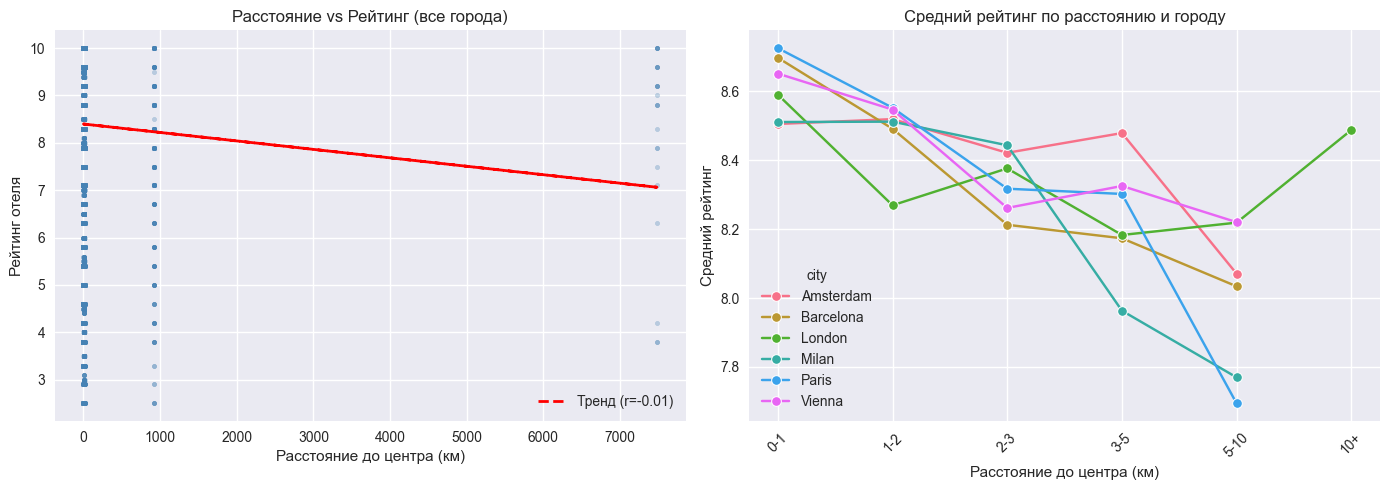

In [602]:


# Настройка стиля
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# === 1. Общая корреляция (все города) ===
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# Scatter plot с прозрачностью и jitter
x = hotels_df['distance_to_center_km']
y = hotels_df['reviewer_score']

# Добавим небольшой шум по X, чтобы точки не налегали
x_jitter = x + np.random.normal(0, 0.05, len(x))

plt.scatter(x_jitter, y, alpha=0.3, s=10, color='steelblue')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Рейтинг отеля')
plt.title('Расстояние vs Рейтинг (все города)')

# Линия тренда
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "r--", linewidth=2, label=f'Тренд (r={np.corrcoef(x, y)[0,1]:.2f})')
plt.legend()

# === 2. По городам (boxplot или lineplot) ===
plt.subplot(1, 2, 2)

# Разобьём расстояние на бины (например, 0-1, 1-2, ..., 10+ км)
hotels_df['distance_bin'] = pd.cut(
    hotels_df['distance_to_center_km'],
    bins=[0, 1, 2, 3, 5, 10, 50],
    labels=['0-1', '1-2', '2-3', '3-5', '5-10', '10+']
)

# Средний рейтинг по бину и городу
grouped = hotels_df.groupby(['city', 'distance_bin'], observed=True)['reviewer_score'].mean().reset_index()

# Lineplot
sns.lineplot(data=grouped, x='distance_bin', y='reviewer_score', hue='city', marker='o')
plt.xlabel('Расстояние до центра (км)')
plt.ylabel('Средний рейтинг')
plt.title('Средний рейтинг по расстоянию и городу')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Удалим временный признак
hotels_df.drop(columns=['distance_bin'], inplace=True)

In [603]:
hotels_df.head()

,index,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,...,reviewer_score,tags,days_since_review,lat,lng,city,azimuth_from_center,azimuth_sin,azimuth_cos,distance_to_center_km
0,0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,...,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531,51.507894,-0.143671,London,273.0,-0.998630,0.052336,1.0
1,1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,...,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203,51.521009,-0.123097,London,12.0,0.207912,0.978148,2.0
2,2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,2016-10-18,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,...,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289,48.845377,2.325643,Paris,237.5,-0.843391,-0.537300,2.0
3,3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,2015-09-22,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,No Negative,0,607,...,10.0,"[' Leisure trip ', ' Solo traveler ', ' Standa...",681,48.888697,2.394540,Paris,41.0,0.656059,0.754710,5.0
4,4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,2016-03-05,8.5,Golden Tulip Amsterdam West,Poland,Torn sheets,4,7586,...,9.6,"[' Business trip ', ' Couple ', ' Standard Dou...",516,52.385601,4.847060,Amsterdam,297.5,-0.887011,0.461749,4.0


**Теперь визуализируем на 3д диаграмме средний рейтинг отеля, и его положение относительно центра города**

In [604]:
import numpy as np

# 1. Агрегация по отелю
hotel_agg = hotels_df.groupby(['hotel_name', 'city']).agg({
    'lat': 'first',
    'lng': 'first',
    'distance_to_center_km': 'first',
    'azimuth_from_center': 'first',
    'reviewer_score': 'mean'
}).reset_index()

# 2. Округление азимута до 0.5°
hotel_agg['azimuth_from_center'] = (hotel_agg['azimuth_from_center'] * 2).round() / 2

# 3. Фильтрация по расстоянию
max_distance = 20
df_plot = hotel_agg[hotel_agg['distance_to_center_km'] <= max_distance].copy()

# 4. Визуализация по городам
cities = df_plot['city'].unique()

for city in cities:
    city_data = df_plot[df_plot['city'] == city]
    if city_data.empty:
        continue
        
    fig = px.scatter_3d(
        city_data,
        x='distance_to_center_km',
        y='azimuth_from_center',
        z='reviewer_score',
        color='reviewer_score',
        color_continuous_scale='Viridis',
        title=f'{city}: уникальные отели (расстояние ≤ {max_distance} км)',
        labels={
            'distance_to_center_km': 'Расстояние до центра (км)',
            'azimuth_from_center': 'Азимут (градусы)',
            'reviewer_score': 'Средний рейтинг отеля'
        },
        opacity=0.8,
        width=800,
        height=600
    )
    
    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[0, max_distance]),
            yaxis=dict(range=[0, 360])
        )
    )
    
    fig.show()

## <font color='orange'>Вывод по результатам анализа пропуска данных:</font>

<font color='lightgreen'>

1. Все пропуски успешно заполнены - данные теперь более точны

2. Видно, что рейтинг имеет четкую тенденцию к снижению по мере увеличения удаления от ценра города, отдельно взятые случаи высокого рейтинга в сучае с Миланом, скорее всего связано с элитной загородной виллой)

3. Также - на 3д диаграмме достаточно хорошо видно, что отели с высокими средними баллами группируются в определенном диапазоне Азимутов и удалений, и причина этому - хорошие районы, которые, очевидно обладают рядом преимуществ и косвенно могут влиять на престиж работы в таком отеле для персонала, доступность инфраструктуры и быстрый доступ к достопримечательностям города.



</font>

In [605]:
# Основные статистики
print("=" * 60)
print("БАЗОВАЯ СТАТИСТИКА РАСПРЕДЕЛЕНИЯ")
print("=" * 60)

stats_summary = hotels_df['distance_to_center_km'].describe()
print(stats_summary)

# Дополнительные статистики
print("\n" + "-" * 60)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 60)

additional_stats = {
    'Медиана': hotels_df['distance_to_center_km'].median(),
    'Мода': hotels_df['distance_to_center_km'].mode().iloc[0] if not hotels_df['distance_to_center_km'].mode().empty else None,
    'Дисперсия': hotels_df['distance_to_center_km'].var(),
    'Коэффициент вариации': (hotels_df['distance_to_center_km'].std() / hotels_df['distance_to_center_km'].mean()) * 100,
    'Асимметрия (skewness)': hotels_df['distance_to_center_km'].skew(),
    'Эксцесс (kurtosis)': hotels_df['distance_to_center_km'].kurtosis(),
    'IQR (межквартильный размах)': stats_summary['75%'] - stats_summary['25%'],
    'Пропуски': hotels_df['distance_to_center_km'].isna().sum(),
    'Процент пропусков': (hotels_df['distance_to_center_km'].isna().sum() / len(hotels_df)) * 100
}

for key, value in additional_stats.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

БАЗОВАЯ СТАТИСТИКА РАСПРЕДЕЛЕНИЯ
count    386803.000000
mean          4.336926
std          66.155336
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        7481.000000
Name: distance_to_center_km, dtype: float64

------------------------------------------------------------
ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:
------------------------------------------------------------
Медиана: 2.0000
Мода: 1.0000
Дисперсия: 4376.5284
Коэффициент вариации: 1525.3969
Асимметрия (skewness): 98.9541
Эксцесс (kurtosis): 10989.8320
IQR (межквартильный размах): 3.0000
Пропуски: 0
Процент пропусков: 0.0000


# 2.3 Обработка ложных отзывов

В negative_review часто встречается "No Negative", "Nothing", "N A" — это не негатив, а отсутствие такового. Аналогично для позитивных.
Однако это лишь беглый взгляд на сам датасет. Необходимо автоматизировать сбор фраз-заглушек и неинфрмативных фраз. Создадим для этого соответствующую функцию.
Логично, что фразы заглушки - это короткие фразы, но не все, некоторые могут содеражать конкретику, например poor breakfast, location. Поэтому для начала создадим список для анализа наиболее часто встречающийся фраз, которые повторяются не менее 10 раз. И проанализируем этот список. В случае, если фраз будет слишком много, можно будет сгруппировать их.

**Для начала посмотрим, какие фразы чаще всего встречаются в негативных и позитивных отзывах.**

In [606]:
top_neg = hotels_df['negative_review'].value_counts().head(20)
print(top_neg)

negative_review
No Negative         95907
 Nothing            10737
 Nothing             3154
 nothing             1660
 N A                  802
 None                 737
                      606
 N a                  384
 Breakfast            296
 Small room           283
 Location             281
 All good             251
 Everything           251
 Nothing really       240
 none                 223
 nothing              219
 No complaints        201
 Nil                  197
 Nothing really       195
 Price                192
Name: count, dtype: int64


In [607]:
top_pos = hotels_df['positive_review'].value_counts().head(20)
print(top_pos)

positive_review
No Positive            26885
 Location               6833
 Everything             1697
 location               1251
 Nothing                 931
 The location            830
 Great location          809
 Good location           690
 Location                663
 Breakfast               455
 Everything              449
 Friendly staff          385
 Staff                   347
 Excellent location      296
 Great location          280
 Location and staff      256
 everything              233
 Good location           214
 Nothing                 170
 nothing                 159
Name: count, dtype: int64


In [608]:
# Определение коротких фраз и фраз- заглушек
from collections import Counter

def extract_common_short_phrases(df, col, min_freq=10, max_words=7):
    """
    Извлекает часто встречающиеся короткие фразы из колонки отзывов.
    
    Parameters:
        df (pd.DataFrame): датафрейм
        col (str): имя колонки с отзывами
        min_freq (int): минимальная частота встречаемости фразы
        max_words (int): максимальное количество слов в фразе
    
    Returns:
        set: множество фраз-кандидатов на заглушки
    """
    # Очистка и нормализация
    reviews = df[col].fillna("").astype(str).str.strip()
    short_reviews = reviews[reviews.str.split().str.len() <= max_words]
    
    # Приведение к нижнему регистру и удаление лишних пробелов
    normalized = short_reviews.str.lower().str.replace(r'\s+', ' ', regex=True)
    
    # Подсчёт частот
    phrase_counts = Counter(normalized)
    
    # Фильтрация по частоте
    common_phrases = {phrase for phrase, cnt in phrase_counts.items() if cnt >= min_freq and len(phrase) > 0}
    
    return common_phrases

common_neg = extract_common_short_phrases(hotels_df, 'negative_review', min_freq=15)
common_pos = extract_common_short_phrases(hotels_df, 'positive_review', min_freq=15)

print (common_neg)

print (common_pos)

{'view from room', 'can t think of a thing', 'bit expensive', 'value for money', 'everything was great', 'nothing worth mentioning', 'noisy', 'pillows too soft', 'the location', 'noting', 'very noisy', 'paid wifi', 'there was nothing we did not like', 'size of room', 'weather', 'price', 'very little', 'nothing comes to mind', 'everything perfect', 'no gym', 'rooms a little small', 'prices', 'couldn t fault anything', 'everything else', 'there was nothing i did not like', 'the room was small', 'breakfast was very expensive', 'poor breakfast', 'going home', 'breakfast could be better', 'everything was good', 'no complaints at all', 'tiny rooms', 'nithing', 'rooms', 'the bathroom', 'price of drinks', 'air conditioning', 'nothing i can think of', 'not applicable', 'no complaints whatsoever', 'the breakfast', 'no bad experience', 'no complains', 'room was too hot', 'bed', 'nothing all perfect', 'perfect', 'no swimming pool', 'rooms were small', 'facilities', 'internet', 'room very small', '

**Выведем фразы с частотами встречаемости**

In [609]:

def normalize_text(text):
    """Нормализует текст: нижний регистр, убирает лишние пробелы и пунктуацию."""
    if pd.isna(text) or str(text).strip() == "":
        return ""
    text = str(text).strip().lower()
    text = re.sub(r'[^a-z\s]', ' ', text)  # оставляем только буквы и пробелы
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_common_short_phrases(df, col, min_freq=15, max_words=7):
    """Возвращает DataFrame с фразами и их частотами из указанной колонки."""
    reviews = df[col].fillna("").astype(str)
    short_reviews = reviews[reviews.str.split().str.len() <= max_words]
    normalized = short_reviews.apply(normalize_text)
    counter = Counter(normalized)
    
    # Фильтрация
    filtered = {
        phrase: count for phrase, count in counter.items()
        if count >= min_freq and len(phrase) > 0
    }
    
    # Преобразуем в DataFrame и сортируем
    df_out = pd.DataFrame(
        list(filtered.items()),
        columns=['phrase', 'frequency']
    ).sort_values(by='frequency', ascending=False).reset_index(drop=True)
    
    return df_out

# Получаем таблицы
neg_phrases_df = get_common_short_phrases(hotels_df, 'negative_review', min_freq=15)
pos_phrases_df = get_common_short_phrases(hotels_df, 'positive_review', min_freq=15)

# Вывод
print("=== ЧАСТО ВСТРЕЧАЮЩИЕСЯ КОРОТКИЕ НЕГАТИВНЫЕ ФРАЗЫ (заглушки) ===")
print(neg_phrases_df.to_string(index=False))

print("\n=== ЧАСТО ВСТРЕЧАЮЩИЕСЯ КОРОТКИЕ ПОЗИТИВНЫЕ ФРАЗЫ (заглушки) ===")
print(pos_phrases_df.to_string(index=False))

=== ЧАСТО ВСТРЕЧАЮЩИЕСЯ КОРОТКИЕ НЕГАТИВНЫЕ ФРАЗЫ (заглушки) ===
                           phrase  frequency
                      no negative      95907
                          nothing      15888
                              n a       1392
                             none       1115
                   nothing really        494
                       small room        424
                         all good        420
                        breakfast        398
                         location        393
                    no complaints        385
                       everything        330
                   nothing at all        329
               nothing to dislike        288
                            price        260
                              nil        259
                      small rooms        229
                               na        205
           everything was perfect        202
               absolutely nothing        182
          can t think of anything  

In [610]:
print("\n=== ЧАСТО ВСТРЕЧАЮЩИЕСЯ КОРОТКИЕ ПОЗИТИВНЫЕ ФРАЗЫ (заглушки) ===")
print(pos_phrases_df.to_string(index=False))


=== ЧАСТО ВСТРЕЧАЮЩИЕСЯ КОРОТКИЕ ПОЗИТИВНЫЕ ФРАЗЫ (заглушки) ===
                                   phrase  frequency
                              no positive      26885
                                 location       8845
                               everything       2455
                                  nothing       1297
                           great location       1291
                             the location       1187
                            good location       1123
                                breakfast        591
                           friendly staff        545
                       excellent location        476
                                    staff        418
                       location and staff        342
                           location staff        316
               location location location        256
                        location was good        243
                       location was great        242
                   everything was

**Итого, мы получили следующий список фраз**

In [611]:
no_content_phrases = {
    "na", "a", 'n', 'a', "no", 'n a', "ok", "all", "nil", "non", "yes", "nada", "none", "nope", "zero",
    "good", "nice", "great", "all ok", "all fine", "all good", "all great", "all perfect",
    "all excellent", "as above", "see above", "not much", "nothing", "nothin", "noting",
    "nithing", "nothing much", "nothing really", "nothing at all", "nothing special",
    "nothing particular", "nothing specific", "nothing of note", "nothing to add",
    "nothing to say", "nothing to report", "nothing to fault", "nothing to dislike",
    "nothing to complain", "nothing to mention", "nothing bad", "nothing negative",
    "no negatives", "no dislikes", "no comment", "no comments", "no issues", "no problems",
    "no faults", "no complaints", "no negative", "no positive", "liked it all", "loved it all",
    "i liked it all", "we liked everything", "i loved everything", "we loved everything",
    "everything", "everthing", "every thing", "every things", "everything else",
    "everything good", "everything nice", "everything fine", "everything perfect",
    "everything was ok", "everything was good", "everything was nice", "everything was great",
    "everything was perfect", "everything was excellent", "everything was fantastic",
    "everything was wonderful", "everything about the hotel", "could not fault anything",
    "can't fault anything", "can't think of anything", "can't think of any",
    "cannot think of anything", "what's not to like", "there was nothing to dislike",
    "there was nothing i didn't like", "there was nothing we didn't like",
    "absolutely nothing", "absolutely everything", "not a thing", "not applicable",
    "no negative comments", "no bad experience", "no bad experiences",
    "no complaints whatsoever", "nothing to complain about", "nothing not to like","nothing all good", "i liked everything",
    "liked everything", "nothing everything was perfect", "nothing it was perfect", "can t think of anything",
    "everything was fine", "all was good", "nothing everything was great", "nothing in particular", "there was nothing i didn t like",
}

**Некоторые фразы в негативных отзывах имеют позитивный отклик, аналогично в позитивных отзывах можно встретить негативные.**
**Это противоречие нельзя однозначно инетерпретировать, поэтому лучше будет вовсе удалить все фразы заглушки.**

In [612]:
def clean_review(text):
    """
    Очищает текст отзыва от типичных заглушек.
    Возвращает пустую строку, если отзыв не содержит реальной критики/похвалы.
    """
    if pd.isna(text):
        return ""
    
    text = str(text).strip().lower()
 
    
    # Проверяем точное совпадение или почти точное
    if text in no_content_phrases or len(text) == 0:
        return ""
    
    # Дополнительно: убираем одиночные символы или цифры без смысла
    if len(text.replace(" ", "")) <= 2 and not any(c.isalpha() for c in text):
        return ""
    
    return text


hotels_df['positive_review'] = hotels_df['positive_review'].apply(clean_review)
hotels_df['negative_review'] = hotels_df['negative_review'].apply(clean_review)

**Теперь еще раз проверим список всех самых распространенных фраз (слов) в положителных и негативных отзывах**

In [613]:
top_neg = hotels_df['negative_review'].value_counts().head(30)
print(top_neg)

negative_review
                           122241
small room                    424
breakfast                     396
location                      393
price                         260
small rooms                   229
leaving                       178
very small room               167
expensive                     156
room size                     148
staff                         132
having to leave               122
expensive breakfast           101
the price                      99
room was very small            96
parking                        90
room too small                 88
pillows                        88
wifi                           81
room very small                80
size of room                   79
room was small                 78
very small rooms               77
no parking                     75
no gym                         74
nothing comes to mind          74
poor breakfast                 73
breakfast too expensive        73
breakfast not included         7

In [614]:
top_pos = hotels_df['positive_review'].value_counts().head(30)

print (top_pos)

positive_review
                              32827
location                       8843
great location                 1291
the location                   1187
good location                  1123
breakfast                       591
friendly staff                  545
excellent location              476
staff                           418
location and staff              341
location staff                  315
location location location      256
location was good               243
location was great              242
comfy bed                       225
good breakfast                  222
perfect location                212
the staff                       208
location is great               204
location is good                188
clean                           181
very friendly staff             178
great breakfast                 171
breakfast was good              170
excellent breakfast             159
very good location              158
location was excellent          152
comfortable 

## <font color='orange'>Вывод по результатам предварительного анализа отзывов:</font>

<font color='lightgreen'>

1. Видно, что **маленькие комнаты** (small room) являются довольно большой долей в негативных отзывах, также людям часто не нравится расположение отеля, завтрак, некоторые жалуются на цены. Также часто встречаются 

2. Позитивные же отзывы чаще хвалят **расположение** (location) - это объективно первое место в рейтинге далее идет персонал, и качеств завтрака

3. Однако набор данных достаточно велик и сплошной перебор всех признаков не отражает распределения по рейтингу. Таким образом, есть смысл разбить рейтинг по группам и проаналиировать распределение негативных или позитивнх фраз (слов) по группам рейтингов.

</font>

# 2.4 Анализ отзывов

## <font color='orange'>Разобьем рейтинг на группы:</font>

<font color='lightgreen'>

1. Низкие (low): 0.0 – 4.0

2. Средние (middle): 4.5 – 6.5

3. Высокие (high): 7.0 – 8.5

4. Отличные (perfect): 9.0 – 10.0
</font>


In [615]:
def score_group_v2(score):
    if score <= 4.0:
        return 'low'
    elif score <= 6.5:
        return 'medium'
    elif score <= 8.5:
        return 'high'
    else:
        return 'perfect'

# Применяем
hotels_df['score_group'] = hotels_df['reviewer_score'].apply(score_group_v2)

# 2.4.1 Определим "Сигнальные фразы" по категориям

**У нас уже есть список топ фраз (слов), которые встречаются в соответствующих отзывах. 
Надо просто выполнить поиск совпадающих слов в этом списке и таким образом мы получим перечень "сигнальных фраз"**

In [616]:
# Создадим функцию для автоматизации составления тем

def extract_keywords_from_top_phrases(top_series, min_word_freq=3):
    phrases = list(top_series.index)
    counts = list(top_series.values)
    
    word_to_phrases = {}
    all_words = []

    # Сбор фраз и слов
    for phrase, count in zip(phrases, counts):
        if not isinstance(phrase, str):
            continue
        words = re.findall(r'[a-zA-Z]{3,}', phrase.lower())
        all_words.extend(words)
        for word in set(words):
            if word not in word_to_phrases:
                word_to_phrases[word] = []
            word_to_phrases[word].append((phrase, count))
    
    # Подсчёт частот вручную
    word_freq = {}
    for word in all_words:
        word_freq[word] = word_freq.get(word, 0) + 1
    
    # Фильтрация и сортировка ключевых слов
    key_words = [word for word, freq in word_freq.items() if freq >= min_word_freq]
    key_words.sort(key=lambda w: -word_freq[w])
    
    # Группировка по темам
    categories = {}
    used_phrases = set()
    
    for word in key_words:
        grouped = []
        for phrase, count in word_to_phrases.get(word, []):
            if phrase not in used_phrases:
                grouped.append((phrase, count))
                used_phrases.add(phrase)
        if grouped:
            categories[word] = grouped
    
    # Остатки
    leftovers = [(p, c) for p, c in zip(phrases, counts) if p not in used_phrases and isinstance(p, str)]
    if leftovers:
        categories['other'] = leftovers
        
    return categories



In [617]:
# Применяем к позитивным и негативным отзывам
print("\n\n=== НЕГАТИВНЫЕ ТЕМЫ ===")
neg_categories = extract_keywords_from_top_phrases(top_neg, min_word_freq=2)

for theme, phrases in neg_categories.items():
    print(f"\n🔸 Тема: '{theme}'")
    for phrase, count in phrases[:5]:
        print(f"  {count:>6} | {phrase}")
        
print("=== ПОЗИТИВНЫЕ ТЕМЫ ===")
pos_categories = extract_keywords_from_top_phrases(top_pos, min_word_freq=2)

for theme, phrases in pos_categories.items():
    print(f"\n🔹 Тема: '{theme}'")
    for phrase, count in phrases[:5]:  # первые 5
        print(f"  {count:>6} | {phrase}")





=== НЕГАТИВНЫЕ ТЕМЫ ===

🔸 Тема: 'small'
     424 | small room
     229 | small rooms
     167 | very small room
      96 | room was very small
      88 | room too small

🔸 Тема: 'room'
     148 | room size
      79 | size of room

🔸 Тема: 'breakfast'
     396 | breakfast
     101 | expensive breakfast
      73 | poor breakfast
      73 | breakfast too expensive
      72 | breakfast not included

🔸 Тема: 'expensive'
     156 | expensive

🔸 Тема: 'price'
     260 | price
      99 | the price

🔸 Тема: 'parking'
      90 | parking
      75 | no parking

🔸 Тема: 'other'
  122241 | 
     393 | location
     178 | leaving
     132 | staff
     122 | having to leave
=== ПОЗИТИВНЫЕ ТЕМЫ ===

🔹 Тема: 'location'
    8843 | location
    1291 | great location
    1187 | the location
    1123 | good location
     476 | excellent location

🔹 Тема: 'good'
     222 | good breakfast
     170 | breakfast was good

🔹 Тема: 'breakfast'
     591 | breakfast
     171 | great breakfast
     159 | excellent

## 2.4.1 Создадим бинарные признаки на основе полученных сигнальных фраз (слов):



In [618]:

# === ОПРЕДЕЛИ КАТЕГОРИИ ЗДЕСЬ ===
# Каждая категория — это список строк или регулярных выражений.
# Используй r'' для regex, обычные строки — для точного совпадения (регистронезависимо).

NEGATIVE_CATEGORIES = {
    'small_room': [
        r'small room',
        r'very small room',
        r'room too small',
        r'room was very small',
        r'room size',
        r'size of room',
        r'tiny room',
    ],
    'expensive': [
        r'expensive',
        r'price',
        r'cost',
        r'overpriced',  
    ],
    'bad_breakfast': [
        r'breakfast',
        r'poor breakfast',
        r'breakfast not included',
        r'expensive breakfast',
        r"poor breakfast",
        r"breakfast too expensive",
        r"breakfast not included",

    ],
    'parking_problem': [
        r'parking',
        r'no parking',
        r'parking fee',
    ],
    'bad_location': [
        r'location'  
        r'far from',
        r'bad location',
        r'not close to',
    ],
    'bad_staff': [
        r'rude staff',
        r'unhelpful staff',
        r'staff was rude',
        r'poor service',
        r'staff',
    ],
    'leaving': [
        r'leave',
        r'leaving',
        r'having to leave',
    ]
}

POSITIVE_CATEGORIES = {
    'good_location': [
        r'location',
        r'great location',
        r'excellent location',
        r'perfect location',
        r'good location',
    ],
    'good_staff': [
        r'friendly staff',
        r'helpful staff',
        r'amazing staff',
        r'professional staff',
        r'staff',
        
    ],
    'good_breakfast': [
        r'breakfast',
        r'great breakfast',
        r'excellent breakfast',
        r'good breakfast',
    ],
    'comfy_bed': [
        r'comfy bed',
        r'comfortable bed',
        r'bed was comfortable',
    ],
    'clean': [
        r'clean',
        r'very clean',
        r'cleanliness',
        r'spotless',
    ]
}

# === ФУНКЦИЯ ДЛЯ СОЗДАНИЯ ПРИЗНАКОВ ===
def create_category_features(df, review_col, categories, prefix):
    """
    Создаёт бинарные признаки на основе заданных категорий и паттернов.
    
    Параметры:
    - df: DataFrame
    - review_col: имя колонки с отзывами (например, 'negative_review')
    - categories: словарь {'название_категории': [паттерны]}
    - prefix: префикс для имён признаков (например, 'neg' или 'pos')
    """
    for category, patterns in categories.items():
        feature_name = f"{prefix}_{category}"
        
        # Объединяем все паттерны в одно регулярное выражение (через OR)
        combined_pattern = '|'.join(patterns)
        
        # Поиск (регистронезависимый, с обработкой NaN)
        df[feature_name] = (
            df[review_col]
            .astype(str)
            .str.contains(combined_pattern, case=False, na=False, regex=True)
        )

# === ПРИМЕНЕНИЕ ===
# Удалим старые признаки (если есть)
cols_to_drop = [col for col in hotels_df.columns if col.startswith(('neg_', 'pos_'))]
hotels_df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# Создаём новые признаки
create_category_features(hotels_df, 'negative_review', NEGATIVE_CATEGORIES, 'neg')
create_category_features(hotels_df, 'positive_review', POSITIVE_CATEGORIES, 'pos')

**Получим списки признаков**

In [619]:
neg_features = [col for col in hotels_df.columns if col.startswith('neg_')]
pos_features = [col for col in hotels_df.columns if col.startswith('pos_')]

print(f"Негативных признаков: {len(neg_features)}")
print(f"Позитивных признаков: {len(pos_features)}")

Негативных признаков: 7
Позитивных признаков: 5


# 2.4.3 Анализ — доля отзывов с признаком в каждой группе

In [620]:
# Для негативных тем
# Таблица: доля (в %) отзывов с признаком в каждой группе
neg_group_dist = []

for feature in neg_features:
    group_counts = hotels_df.groupby('score_group')[feature].mean() * 100  # доля в %
    row = {'feature': feature}
    for group in ['low', 'medium', 'high', 'perfect']:
        row[group] = round(group_counts.get(group, 0), 2)
    neg_group_dist.append(row)

neg_summary = pd.DataFrame(neg_group_dist).set_index('feature')
print("=== НЕГАТИВНЫЕ ТЕМЫ: доля (%) по группам рейтинга ===")
print(neg_summary)

=== НЕГАТИВНЫЕ ТЕМЫ: доля (%) по группам рейтинга ===
                       low  medium   high  perfect
feature                                           
neg_small_room        5.06    6.83   3.98     0.84
neg_expensive        11.26   13.46   9.83     5.57
neg_bad_breakfast    12.50   14.67  12.40     7.14
neg_parking_problem   2.12    2.01   1.80     1.10
neg_bad_location      0.30    0.14   0.04     0.02
neg_bad_staff        28.33   19.78   8.45     2.71
neg_leaving           2.60    1.76   0.93     0.63


In [621]:
# Для позитивных тем

pos_group_dist = []

for feature in pos_features:
    group_counts = hotels_df.groupby('score_group')[feature].mean() * 100
    row = {'feature': feature}
    for group in ['low', 'medium', 'high', 'perfect']:
        row[group] = round(group_counts.get(group, 0), 2)
    pos_group_dist.append(row)

pos_summary = pd.DataFrame(pos_group_dist).set_index('feature')
print("\n=== ПОЗИТИВНЫЕ ТЕМЫ: доля (%) по группам рейтинга ===")
print(pos_summary)


=== ПОЗИТИВНЫЕ ТЕМЫ: доля (%) по группам рейтинга ===
                      low  medium   high  perfect
feature                                          
pos_good_location   19.00   36.26  39.44    36.03
pos_good_staff       6.52   15.26  29.23    45.95
pos_good_breakfast   4.83    9.46  15.61    17.88
pos_comfy_bed        0.78    2.32   4.40     4.97
pos_clean            2.64    7.44  14.31    16.74


## <font color='orange'>Вывод по результатам постанализа отзываов:</font>

<font color='lightgreen'>

**1. Негативные темы:**

  а. Расположение (neg_location) не дает даже процента - во всех случаях ниже половины процента = однозначно можно удалить
  b. Парковка (neg_parking), neg_leaving - под вопросом - требуется дополнительная проверка
  c. Маленькие комнаты чаще фигурируют в самых низких рейтингах, частота встречаемости падает с ростом рейтинга отеля, отчетливо видно, что низкое качество завтрака, дороговизна, а также плохой персонал больше всего встречается в низких рейтингах отеля - однозначно важные признаки

**2. Позтивные темы:**

 Все признаки явно актуальны - отчетливо видно, как частота встречаемости всех тем растет вместе с рейтингом отеля 

</font>

**Проанализируем влияние признака на рейтинг - просто сравним средний рейтинг с признаком и без него**

In [622]:
def analyze_feature_impact(feature):
    with_feat = hotels_df[hotels_df[feature]]
    without_feat = hotels_df[~hotels_df[feature]]
    
    mean_with = with_feat['reviewer_score'].mean()
    mean_without = without_feat['reviewer_score'].mean()
    diff = mean_without - mean_with  # насколько снижает
    
    count_with = len(with_feat)
    pct_low_with = (with_feat['score_group'] == 'low').mean() * 100
    
    print(f"Признак: {feature}")
    print(f"  Средний рейтинг с признаком: {mean_with:.2f}")
    print(f"  Средний рейтинг без признака: {mean_without:.2f}")
    print(f"  Снижение оценки: {diff:.2f} баллов")
    print(f"  Количество отзывов: {count_with}")
    print(f"  Доля 'low' среди них: {pct_low_with:.2f}%")
    print("-" * 50)

# Анализируем оба признака
analyze_feature_impact('neg_parking_problem')
analyze_feature_impact('neg_leaving')

Признак: neg_parking_problem
  Средний рейтинг с признаком: 7.92
  Средний рейтинг без признака: 8.40
  Снижение оценки: 0.48 баллов
  Количество отзывов: 5528
  Доля 'low' среди них: 3.09%
--------------------------------------------------
Признак: neg_leaving
  Средний рейтинг с признаком: 7.62
  Средний рейтинг без признака: 8.40
  Снижение оценки: 0.78 баллов
  Количество отзывов: 3427
  Доля 'low' среди них: 6.13%
--------------------------------------------------


<font color='lightgreen'>

**Вывод:** 

***neg_parking_problem*** не дает и половины процента - однозначно удаляем

**Оценим статистическую значимость neg_leaving - (проблемы с выездом) приняв p-value = 0.05. Метод - Хи-квадрат**

In [623]:
from scipy.stats import chi2_contingency

for feature in ['neg_leaving']:
    contingency = pd.crosstab(hotels_df[feature], hotels_df['score_group'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{feature}: p-value = {p:.2e} → {'значим' if p < 0.05 else 'НЕ значим'}")

neg_leaving: p-value = 9.79e-175 → значим


<font color='lightgreen'>

**Вывод:**

***neg_leaving*** дает некоторую значимость - пока все еще сомнительно, но оставим, проверим как пойдет обучение модели**

In [624]:
# Удаляем neg_parking_problem
col_to_drop = 'neg_parking_problem'



In [625]:
hotels_df.head()

,index,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,...,neg_bad_breakfast,neg_parking_problem,neg_bad_location,neg_bad_staff,neg_leaving,pos_good_location,pos_good_staff,pos_good_breakfast,pos_comfy_bed,pos_clean
0,0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,leaving,3,1994,...,False,False,False,False,True,False,True,False,False,False
1,1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,...,True,False,False,False,False,True,False,False,False,False
2,2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,2016-10-18,8.9,Legend Saint Germain by Elegancia,China,no kettle in room,6,406,...,False,False,False,False,False,False,False,False,False,False
3,3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,2015-09-22,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,,0,607,...,False,False,False,False,False,True,True,False,False,True
4,4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,2016-03-05,8.5,Golden Tulip Amsterdam West,Poland,torn sheets,4,7586,...,False,False,False,False,False,False,True,True,False,True


## 2.5 Дата отзыва ***review_date***

**Извлечем из даты отзыва сезон (review_season), викэнд (is_weekend), а также год (review_year)**

In [626]:
# Убедимся, что review_date уже имеет тип datetime
hotels_df['review_date'] = pd.to_datetime(hotels_df['review_date'])

In [627]:
# 1. Год
hotels_df['review_year'] = hotels_df['review_date'].dt.year

# 2. Выходной день (суббота=5, воскресенье=6)
hotels_df['is_weekend'] = hotels_df['review_date'].dt.dayofweek.isin([5, 6])

# 3. Сезон (числовое кодирование: 0=зима, 1=весна, 2=лето, 3=осень)
def get_season_num(month):
    if month in [12, 1, 2]:
        return 0  # зима
    elif month in [3, 4, 5]:
        return 1  # весна
    elif month in [6, 7, 8]:
        return 2  # лето
    else:
        return 3  # осень

hotels_df['review_season'] = hotels_df['review_date'].dt.month.apply(get_season_num)

## 2.6 Анализ ***reviewer_nationality***

2.6.1 Очистка и нормализация

In [628]:
# Уберём лишние пробелы
hotels_df['reviewer_nationality'] = hotels_df['reviewer_nationality'].str.strip()

# Пример: " United Kingdom " → "United Kingdom"

In [629]:
# Топ-15 национальностей
print("Топ-15 национальностей:")
print(hotels_df['reviewer_nationality'].value_counts().head(15))

# Сколько всего уникальных?
n_unique = hotels_df['reviewer_nationality'].nunique()
print(f"\nВсего уникальных национальностей: {n_unique}")

# Доля топ-10
top10_count = hotels_df['reviewer_nationality'].value_counts().head(10).sum()
total = len(hotels_df)
print(f"Доля топ-10: {top10_count / total:.2%}")

Топ-15 национальностей:
reviewer_nationality
United Kingdom              184033
United States of America     26541
Australia                    16239
Ireland                      11126
United Arab Emirates          7617
Saudi Arabia                  6722
Netherlands                   6608
Switzerland                   6498
Canada                        5984
Germany                       5956
France                        5543
Israel                        4918
Italy                         4562
Belgium                       4529
Turkey                        4105
Name: count, dtype: int64

Всего уникальных национальностей: 225
Доля топ-10: 71.70%


## <font color='orange'>Предварительный вывод по результатам обзора *reviewer_nationality*:</font>

<font color='lightgreen'>

1. Уникальных национальностей слишком много - создавать для каждой из них отдельный признак нецелесообразно, достаточно будет выбрать топ-15 и other.
    Также - необходимо сгруппировать национальности по регионам, для чего произвести маппинг, а также создать признак hotel_country

2. Также - полезно будет создать признаки поездки внутри страны гражданства и региона и посмотреть зависимости, чтобы убедиться в пользе созданных признаков.

</font>

## Топ-15 национальностей + 'Other'

In [630]:
top15_nats = hotels_df['reviewer_nationality'].value_counts().head(15).index
hotels_df['reviewer_nationality_clean'] = (
    hotels_df['reviewer_nationality']
    .where(hotels_df['reviewer_nationality'].isin(top15_nats), 'Other')
)

## Страна отеля

In [631]:
def extract_country(address):
    parts = address.split()
    if parts[-1] == 'Kingdom':
        return 'United Kingdom'
    else:
        return parts[-1]

hotels_df['hotel_country'] = hotels_df['hotel_address'].apply(extract_country)

## Маппинг стран → регионов

In [632]:
# Расширенный маппинг (можно дополнить)
country_to_region = {
    # Europe
    'United Kingdom': 'Europe',
    'France': 'Europe',
    'Germany': 'Europe',
    'Italy': 'Europe',
    'Spain': 'Europe',
    'Netherlands': 'Europe',
    'Russia': 'Europe',
    'Ireland': 'Europe',
    'Belgium': 'Europe',
    'Switzerland': 'Europe',
    'Austria': 'Europe',
    'Portugal': 'Europe',
    'Sweden': 'Europe',
    'Norway': 'Europe',
    'Denmark': 'Europe',
    'Poland': 'Europe',
    'Greece': 'Europe',
    'Czech Republic': 'Europe',
    'Hungary': 'Europe',
    'Romania': 'Europe',
    'Ukraine': 'Europe',
    
    # North America
    'United States of America': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'USA': 'North America',
    
    # Asia
    'China': 'Asia',
    'India': 'Asia',
    'Japan': 'Asia',
    'South Korea': 'Asia',
    'Singapore': 'Asia',
    'Malaysia': 'Asia',
    'Thailand': 'Asia',
    'Indonesia': 'Asia',
    'Philippines': 'Asia',
    'Vietnam': 'Asia',
    
    
    # Middle East
    'Saudi Arabia': 'Middle East',
    'United Arab Emirates': 'Middle East',
    'Qatar': 'Middle East',
    'Kuwait': 'Middle East',
    'Oman': 'Middle East',
    'Bahrain': 'Middle East',
    'Israel': 'Middle East',
    
    # Oceania
    'Australia': 'Oceania',
    'New Zealand': 'Oceania',
    
    # South America
    'Brazil': 'South America',
    'Argentina': 'South America',
    'Chile': 'South America',
    'Colombia': 'South America',
    
    # Africa
    'South Africa': 'Africa',
    'Egypt': 'Africa',
    'Morocco': 'Africa',
    'Nigeria': 'Africa',
    'Kenya': 'Africa'
}

# Применяем
hotels_df['reviewer_region'] = hotels_df['reviewer_nationality'].map(country_to_region).fillna('Other')
hotels_df['hotel_region'] = hotels_df['hotel_country'].map(country_to_region).fillna('Other')

## 2.6.2 Создаем признаки is_domestic_trip,  is_regional_trip

In [633]:
# 1. Domestic trip: страна туриста == страна отеля
hotels_df['is_domestic_trip'] = (
    hotels_df['reviewer_nationality'] == hotels_df['hotel_country']
)

# 2. Regional trip: регион туриста == регион отеля
hotels_df['is_regional_trip'] = (
    hotels_df['reviewer_region'] == hotels_df['hotel_region']
)

**Средний рейтинг по типу поездки**

In [634]:
print("Средний рейтинг по типу поездки:")
print(hotels_df.groupby('is_domestic_trip')['reviewer_score'].agg(['mean', 'count']))
print("\nСредний рейтинг по региональной поездке:")
print(hotels_df.groupby('is_regional_trip')['reviewer_score'].agg(['mean', 'count']))

Средний рейтинг по типу поездки:
                      mean   count
is_domestic_trip                  
False             8.385857  252862
True              8.417766  133941

Средний рейтинг по региональной поездке:
                      mean   count
is_regional_trip                  
False             8.366913  130360
True              8.412153  256443


In [635]:

# === 1. Domestic trip по группам рейтинга ===
print("=== ДОМАШНИЕ ПОЕЗДКИ (is_domestic_trip) по группам рейтинга ===")
domestic_dist = pd.crosstab(
    hotels_df['score_group'], 
    hotels_df['is_domestic_trip'], 
    normalize='index'  # доля внутри каждой группы
) * 100

domestic_dist = domestic_dist.round(2)
print(domestic_dist)
print("\n")

# === 2. Regional trip по группам рейтинга ===
print("=== РЕГИОНАЛЬНЫЕ ПОЕЗДКИ (is_regional_trip) по группам рейтинга ===")
regional_dist = pd.crosstab(
    hotels_df['score_group'], 
    hotels_df['is_regional_trip'], 
    normalize='index'
) * 100

regional_dist = regional_dist.round(2)
print(regional_dist)

=== ДОМАШНИЕ ПОЕЗДКИ (is_domestic_trip) по группам рейтинга ===
is_domestic_trip  False  True 
score_group                   
high              65.96  34.04
low               67.27  32.73
medium            64.88  35.12
perfect           65.09  34.91


=== РЕГИОНАЛЬНЫЕ ПОЕЗДКИ (is_regional_trip) по группам рейтинга ===
is_regional_trip  False  True 
score_group                   
high              33.79  66.21
low               39.02  60.98
medium            34.07  65.93
perfect           33.39  66.61


In [636]:
print("\n=== Средний рейтинг по типу поездки ===")
print("Domestic trip:")
print(hotels_df.groupby('is_domestic_trip')['reviewer_score'].agg(['mean', 'count']))

print("\nRegional trip:")
print(hotels_df.groupby('is_regional_trip')['reviewer_score'].agg(['mean', 'count']))


=== Средний рейтинг по типу поездки ===
Domestic trip:
                      mean   count
is_domestic_trip                  
False             8.385857  252862
True              8.417766  133941

Regional trip:
                      mean   count
is_regional_trip                  
False             8.366913  130360
True              8.412153  256443


## <font color='orange'>Результат обзора *is_domestic_trip* и  *is_regional_trip*:</font>

<font color='lightgreen'>

Можно заметить, что средний рейтинг в поездках по своему региону и внутри своей страны все же немного выше, а то же время, доля обоих признаков немного выше в высоких группах рейтинга. Для того, чтобы понять, оставить эти признаки или нет - лучше проверить статистическую значимость. Предварительно изучить влияние национальности на рейтинг.



</font>

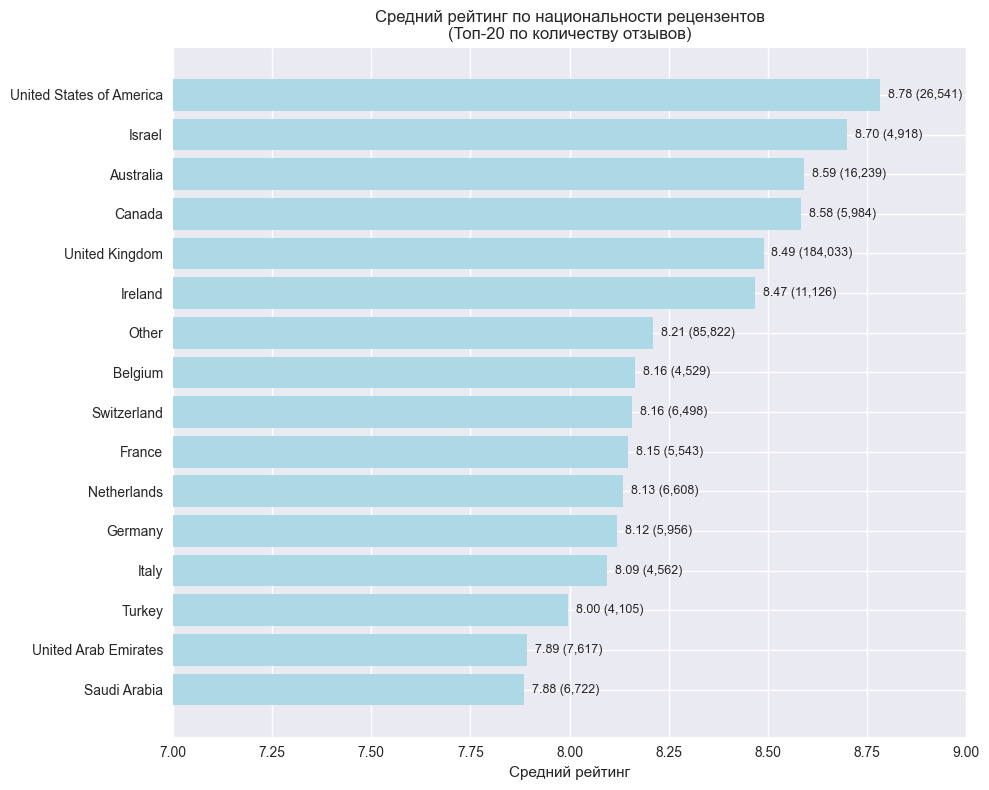

In [637]:

# Группируем по очищенной национальности (топ-15 + Other)
avg_rating_by_nat = (
    hotels_df.groupby('reviewer_nationality_clean')['reviewer_score']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

# Берём топ-20 по количеству отзывов (чтобы избежать шума от редких стран)
top20_by_count = avg_rating_by_nat.sort_values('count', ascending=False).head(20)
# Сортируем их по среднему рейтингу
top20_sorted = top20_by_count.sort_values('mean', ascending=True)  # от низких к высоким

# Визуализация
plt.figure(figsize=(10, 8))
bars = plt.barh(
    top20_sorted.index, 
    top20_sorted['mean'], 
    color='lightblue'
)

# Добавляем значения на график
for bar, mean_val, count_val in zip(bars, top20_sorted['mean'], top20_sorted['count']):
    plt.text(
        bar.get_width() + 0.02, 
        bar.get_y() + bar.get_height()/2, 
        f'{mean_val:.2f} ({count_val:,})',
        va='center',
        fontsize=9
    )

plt.title('Средний рейтинг по национальности рецензентов\n(Топ-20 по количеству отзывов)')
plt.xlabel('Средний рейтинг')
plt.xlim(7.0, 9.0)
plt.tight_layout()
plt.show()

**Отчетливо видно, что наиболее низкие рейтнги дают туристы из богатых стран Ближнего Востока, а также Турции, это явное влияние культурного кода.
В то время, как самые высокие рейтинги у граждан Израиля, США, Австралии - то есть более Европеизированного населения**

## 2.6.3 Проверка статистической значимости новых признаков

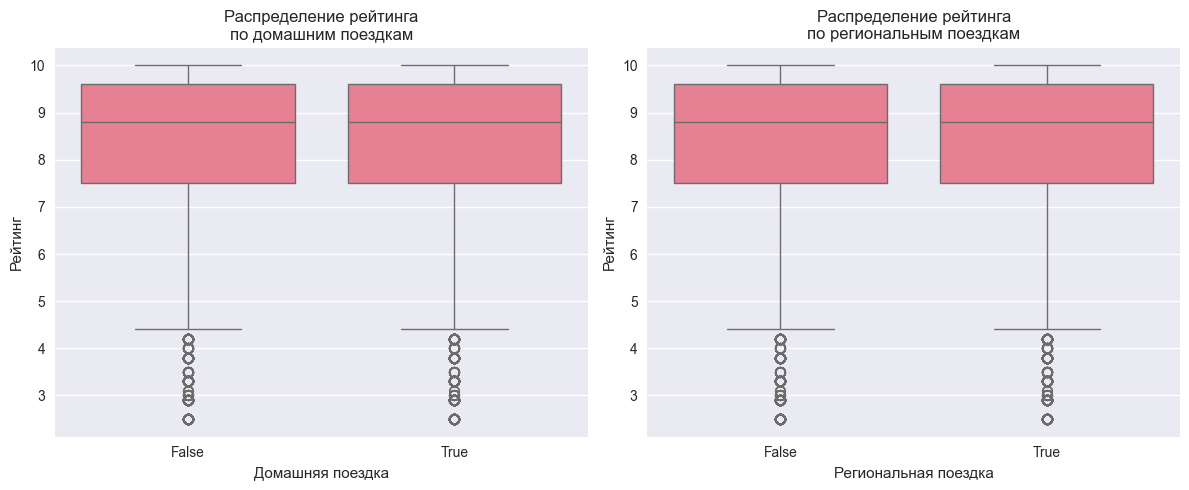

In [638]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 1. Domestic trip
plt.subplot(1, 2, 1)
sns.boxplot(data=hotels_df, x='is_domestic_trip', y='reviewer_score')
plt.title('Распределение рейтинга\nпо домашним поездкам')
plt.xlabel('Домашняя поездка')
plt.ylabel('Рейтинг')

# 2. Regional trip
plt.subplot(1, 2, 2)
sns.boxplot(data=hotels_df, x='is_regional_trip', y='reviewer_score')
plt.title('Распределение рейтинга\nпо региональным поездкам')
plt.xlabel('Региональная поездка')
plt.ylabel('Рейтинг')

plt.tight_layout()
plt.show()

In [639]:
from scipy.stats import ttest_ind

def test_significance(feature):
    group_true = hotels_df[hotels_df[feature]]['reviewer_score']
    group_false = hotels_df[~hotels_df[feature]]['reviewer_score']
    
    t_stat, p_val = ttest_ind(group_true, group_false, equal_var=False)  # Welch's t-test
    
    print(f"Признак: {feature}")
    print(f"  Среднее (True):  {group_true.mean():.4f}")
    print(f"  Среднее (False): {group_false.mean():.4f}")
    print(f"  t-статистика: {t_stat:.4f}")
    print(f"  p-value: {p_val:.2e}")
    print(f"  Значим при α=0.05? {'✅ Да' if p_val < 0.05 else '❌ Нет'}")
    print("-" * 50)

# Проверяем оба признака
test_significance('is_domestic_trip')
test_significance('is_regional_trip')

Признак: is_domestic_trip
  Среднее (True):  8.4178
  Среднее (False): 8.3859
  t-статистика: 5.7548
  p-value: 8.68e-09
  Значим при α=0.05? ✅ Да
--------------------------------------------------
Признак: is_regional_trip
  Среднее (True):  8.4122
  Среднее (False): 8.3669
  t-статистика: 8.0649
  p-value: 7.36e-16
  Значим при α=0.05? ✅ Да
--------------------------------------------------


## <font color='orange'>Вывод по анализу *is_domestic_trip* и  *is_regional_trip*:</font>

<font color='lightgreen'>

Оба признака имеют статистическую значимость. Оставляем их для использования в обучении модели

In [640]:
hotels_df.head()

,index,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,...,pos_clean,review_year,is_weekend,review_season,reviewer_nationality_clean,hotel_country,reviewer_region,hotel_region,is_domestic_trip,is_regional_trip
0,0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,leaving,3,1994,...,False,2016,False,0,United Kingdom,United Kingdom,Europe,Europe,True,True
1,1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,...,False,2017,False,0,United Kingdom,United Kingdom,Europe,Europe,True,True
2,2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,2016-10-18,8.9,Legend Saint Germain by Elegancia,China,no kettle in room,6,406,...,False,2016,False,3,Other,France,Asia,Europe,False,False
3,3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,2015-09-22,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,,0,607,...,True,2015,False,3,United Kingdom,France,Europe,Europe,False,True
4,4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,2016-03-05,8.5,Golden Tulip Amsterdam West,Poland,torn sheets,4,7586,...,True,2016,True,1,Other,Netherlands,Europe,Europe,False,True


## **2.7.**  Анализ *tags*

**Цель:**

**Отбор нужных тегов для создания бинарных (или кодированых) признаков**

## 2.7.1 Обработка тегов — извлечение ключевых категорий

In [641]:
# Функция для парсинга тегов
def parse_tags(tag_str):
    if pd.isna(tag_str):
        return []
    tags = re.findall(r"'([^']*)'", str(tag_str))
    return [t.strip() for t in tags if t.strip()]

# Применяем
hotels_df['parsed_tags'] = hotels_df['tags'].apply(parse_tags)

# Собираем все теги
all_tags = []
for tag_list in hotels_df['parsed_tags']:
    all_tags.extend(tag_list)

# Получаем топ-20 как словарь
top20_tags_dict = dict(Counter(all_tags).most_common(20))

# Вывод
print("Топ-20 тегов:")
for tag, cnt in top20_tags_dict.items():
    print(f"{cnt:>6} | {tag}")

Топ-20 тегов:
313593 | Leisure trip
230778 | Submitted from a mobile device
189212 | Couple
145373 | Stayed 1 night
100263 | Stayed 2 nights
 81235 | Solo traveler
 72000 | Stayed 3 nights
 61989 | Business trip
 49088 | Group
 45836 | Family with young children
 35748 | Stayed 4 nights
 26386 | Double Room
 24151 | Standard Double Room
 23550 | Superior Double Room
 19802 | Family with older children
 18623 | Deluxe Double Room
 16824 | Double or Twin Room
 15611 | Stayed 5 nights
 13062 | Standard Double or Twin Room
 12716 | Classic Double Room


In [642]:
# Вывод в процентах
total_reviews = len(hotels_df)
print("Топ-20 тегов (% от общего числа отзывов):")
for tag, count in top20_tags_dict.items():
    pct = (count / total_reviews) * 100
    print(f"{pct:6.2f}% | {tag}")

Топ-20 тегов (% от общего числа отзывов):
 81.07% | Leisure trip
 59.66% | Submitted from a mobile device
 48.92% | Couple
 37.58% | Stayed 1 night
 25.92% | Stayed 2 nights
 21.00% | Solo traveler
 18.61% | Stayed 3 nights
 16.03% | Business trip
 12.69% | Group
 11.85% | Family with young children
  9.24% | Stayed 4 nights
  6.82% | Double Room
  6.24% | Standard Double Room
  6.09% | Superior Double Room
  5.12% | Family with older children
  4.81% | Deluxe Double Room
  4.35% | Double or Twin Room
  4.04% | Stayed 5 nights
  3.38% | Standard Double or Twin Room
  3.29% | Classic Double Room


In [643]:
# Получаем список топ-20 тегов в виде словаря (только названия)
top20_tags_list = [tag for tag, count in Counter(all_tags).most_common(20)]

print (top20_tags_list)

['Leisure trip', 'Submitted from a mobile device', 'Couple', 'Stayed 1 night', 'Stayed 2 nights', 'Solo traveler', 'Stayed 3 nights', 'Business trip', 'Group', 'Family with young children', 'Stayed 4 nights', 'Double Room', 'Standard Double Room', 'Superior Double Room', 'Family with older children', 'Deluxe Double Room', 'Double or Twin Room', 'Stayed 5 nights', 'Standard Double or Twin Room', 'Classic Double Room']


## <font color='orange'>Вывод по анализу *tags*:</font>

<font color='lightgreen'>

1. Тег *Submitted from a mobile device* - не информативны, встречаются почти везде, что не удивительно в эпоху интернета. можно удалить

2. Теги ипа *Stayed Х night* - дублируется, так как уже есть отдельный признак, отвечающий за это.

3. Слишком редкие теги (<5% упоминаний) точно никак не смогут помочь.

**Финальный список тегов для бинарных признаков:**

In [644]:
meaningful_tags = [
    'Leisure trip',
    'Business trip',
    'Couple',
    'Solo traveler',
    'Family with young children',  # объединить в 'is_family'
    'Family with older children',  # объединить в 'is_family'
    'Group'
]

## 2.7.2 Cоздание финальных теговых признаков:

In [645]:
# 1. Семья (любой тип)
hotels_df['tag_is_family'] = hotels_df['parsed_tags'].apply(
    lambda tags: ('Family with young children' in tags) or 
                 ('Family with older children' in tags)
)

# 2. Остальные смысловые теги
other_tags = [
    'Leisure trip',
    'Business trip',
    'Couple',
    'Solo traveler',
    'Group'
]

for tag in other_tags:
    col_name = f"tag_{tag.lower().replace(' ', '_')}"
    hotels_df[col_name] = hotels_df['parsed_tags'].apply(lambda tags: tag in tags)

print("✅ Созданы теговые признаки:")
print("- tag_is_family")
for tag in other_tags:
    print(f"- tag_{tag.lower().replace(' ', '_')}")

✅ Созданы теговые признаки:
- tag_is_family
- tag_leisure_trip
- tag_business_trip
- tag_couple
- tag_solo_traveler
- tag_group


## **2.8.**  Мультиколлинеарность

Цель:

Найти и удалить сильно коррелирующие признаки (|r| > 0.9), чтобы:

Упростить модель,
Улучшить стабильность коэффициентов
Избежать "размывания" важности признаков.

## **2.8.1** Выберем числовые признаки для анализа

In [646]:
hotels_df.head()

,index,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,...,hotel_region,is_domestic_trip,is_regional_trip,parsed_tags,tag_is_family,tag_leisure_trip,tag_business_trip,tag_couple,tag_solo_traveler,tag_group
0,0,Stratton Street Mayfair Westminster Borough Lo...,581,2016-02-19,8.4,The May Fair Hotel,United Kingdom,leaving,3,1994,...,Europe,True,True,"[Leisure trip, Couple, Studio Suite, Stayed 2 ...",False,True,False,True,False,False
1,1,130 134 Southampton Row Camden London WC1B 5AF...,299,2017-01-12,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,...,Europe,True,True,"[Business trip, Couple, Standard Double Room, ...",False,False,True,True,False,False
2,2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,2016-10-18,8.9,Legend Saint Germain by Elegancia,China,no kettle in room,6,406,...,Europe,False,False,"[Leisure trip, Solo traveler, Modern Double Ro...",False,True,False,False,True,False
3,3,216 Avenue Jean Jaures 19th arr 75019 Paris Fr...,34,2015-09-22,7.5,Mercure Paris 19 Philharmonie La Villette,United Kingdom,,0,607,...,Europe,False,True,"[Leisure trip, Solo traveler, Standard Room wi...",False,True,False,False,True,False
4,4,Molenwerf 1 1014 AG Amsterdam Netherlands,914,2016-03-05,8.5,Golden Tulip Amsterdam West,Poland,torn sheets,4,7586,...,Europe,False,True,"[Business trip, Couple, Standard Double or Twi...",False,False,True,True,False,False


In [647]:
# Исключим ненужные колонки
exclude_cols = [
    'hotel_name', 'hotel_address', 'review_date', 
    'reviewer_nationality', 'tags', 'days_since_review',
    'score_group', 'city'  # city — категориальный, не для корреляции
]

# Оставим только числовые и бинарные
numeric_cols = hotels_df.select_dtypes(include=['number', 'bool']).columns
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Числовых признаков для анализа: {len(numeric_cols)}")

Числовых признаков для анализа: 37


## **2.8.2** Построим матрицу корреляции

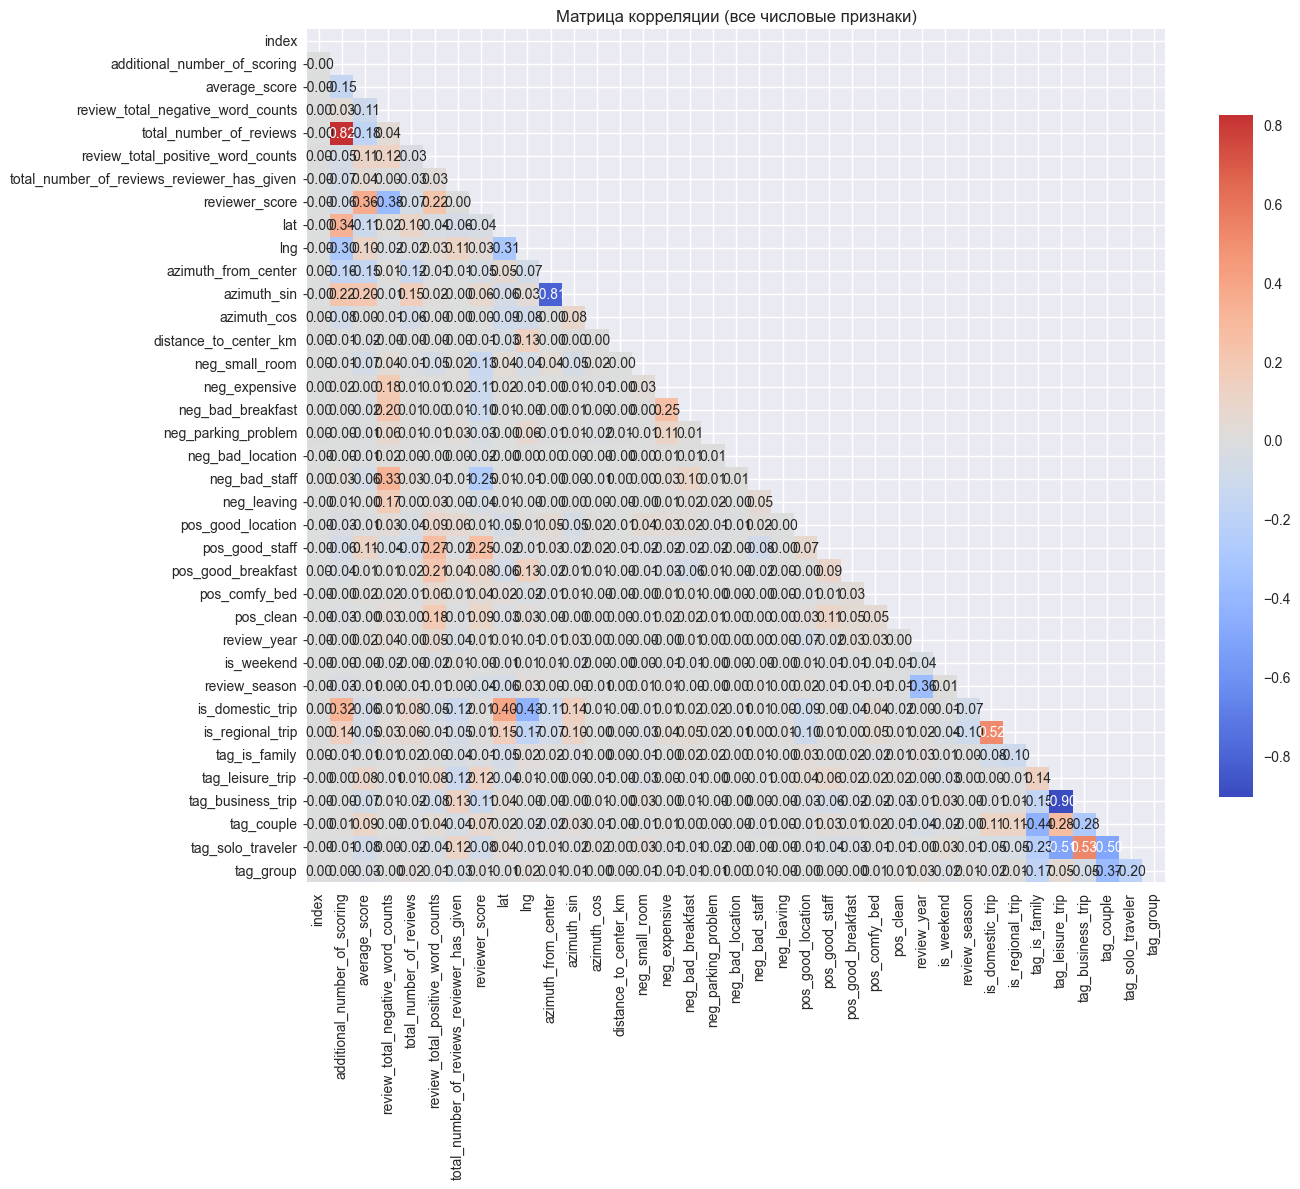

In [648]:

# Матрица корреляции
corr_matrix = hotels_df[numeric_cols].corr()

# Визуализация (только |r| > 0.7)
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Только нижний треугольник
sns.heatmap(
    corr_matrix.mask(mask),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    cbar_kws={'shrink': 0.8}
)
plt.title('Матрица корреляции (все числовые признаки)')
plt.tight_layout()
plt.show()

**Неплохая попытка, но матрица, ожидаема получилась слишком огромной, чтобы ее можно было анализировать, перейдем к функции поиска сильно кореллирующих пар**

## **2.8.3** Ищем сильно коррелирующие пары (|r| > 0.9)

In [649]:
def find_high_corr_pairs(corr_matrix, threshold=0.9):
    pairs = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if abs(val) > threshold:
                pairs.append((cols[i], cols[j], val))
    return pairs

high_corr_pairs = find_high_corr_pairs(corr_matrix, threshold=0.9)

if high_corr_pairs:
    print("Сильно коррелирующие пары (|r| > 0.9):")
    for col1, col2, r in high_corr_pairs:
        print(f"{col1} ↔ {col2}: r = {r:.3f}")
else:
    print("Нет сильно коррелирующих пар (|r| > 0.9).")

Сильно коррелирующие пары (|r| > 0.9):
tag_leisure_trip ↔ tag_business_trip: r = -0.904


## <font color='orange'>Вывод:</font>

<font color='lightgreen'>

Логично, что это сильно кореллирующие пары, потому, что поездки в принципе бывают двух типов - по работе и по отдыху, третьего варианта просто нет. 
Это как в случае с двумя носками, если один надеть на левую ногу, то второй сразу становится правым.

Снимать гостиницу в качестве постоянного жилья едва ли возможо из-за дороговизны. Возможно есть такие уникальные случаи, но они слишком редки в объективной реальности. Поэтому можно признак ***tag_leisure_trip*** оставить, удалив дублирующий его признак рабочей поездки

In [650]:
# Удаляем tag_business_trip
hotels_df.drop(columns=['tag_business_trip'], inplace=True)


## **2.9** Финальный отбор признаков

## 2.9.1 Удаляем ненужные колонки

In [651]:
# Колонки, которые точно не нужны в модели
cols_to_remove = [
    'hotel_name',
    'hotel_address',
    'review_date',
    'reviewer_nationality',      # заменён на cleaned версию
    'tags',                      # уже обработан
    'parsed_tags',               # временная
    'center_lat', 'center_lng',  # если остались
    'days_since_review',         # если есть
    'score_group',               # целевая — reviewer_score
    'tag_business_trip',         # удалён из-за мультиколлинеарности
    'positive_review',
    'negative_review',
]

# Удаляем, если существуют
hotels_df.drop(columns=[c for c in cols_to_remove if c in hotels_df.columns], inplace=True)

## 2.9.2 Проверим и удалим утечки данных (data leakage)

Критически важно: признаки, содержащие информацию о рейтинге до его появления, нельзя использовать.

Проблема: ***average_score***

На момент написания нового отзыва средний рейтинг ещё не включает этот отзыв.
Но в датасете average_score уже включает все отзывы, в том числе и тот, который мы пытаемся предсказать.

***additional_number_of_scoring*** — тоже утечка
Этот признак обычно означает:
«Количество людей, которые оценили отель, но не оставили текстового отзыва».

Но:

Эти оценки тоже влияют на average_score.
И они накапливаются со временем.
На момент написания конкретного отзыва это число ещё не включает будущие оценки.

In [652]:
#  удаление 'average_score', 'additional_number_of_scoring'
hotels_df.drop(columns=['average_score', 'additional_number_of_scoring'], errors='ignore', inplace=True)

## **ЧАСТЬ 3.** Обучение модели

## 3.1 Определим категориальные и числовые признаки

## 3.2 Подготовка X и y

In [653]:
# 1. Определим все колонки-признаки (без целевой переменной)
all_feature_cols = [col for col in hotels_df.columns if col != 'reviewer_score']

# 2. Определим категориальные признаки (object-типы)
cat_features = hotels_df[all_feature_cols].select_dtypes(include=['object']).columns.tolist()

# 3. Числовые/бинарные — всё остальное
num_features = [col for col in all_feature_cols if col not in cat_features]

print(f"🔤 Категориальных признаков: {len(cat_features)}")
print("Категориальные признаки:", cat_features)
print(f"🔢 Числовых/бинарных признаков: {len(num_features)}")

# 4. Теперь создаём X и y
X = hotels_df[all_feature_cols]  # или hotels_df[num_features + cat_features]
y = hotels_df['reviewer_score']

print(f"\n🎯 Финальный датасет:")
print(f"   Признаков: {X.shape[1]}")
print(f"   Наблюдений: {X.shape[0]}")
print(f"   Категориальных: {len(cat_features)}")

🔤 Категориальных признаков: 5
Категориальные признаки: ['city', 'reviewer_nationality_clean', 'hotel_country', 'reviewer_region', 'hotel_region']
🔢 Числовых/бинарных признаков: 33

🎯 Финальный датасет:
   Признаков: 38
   Наблюдений: 386803
   Категориальных: 5


## 3.3 Валидация признаков

## 3.3.1 Подготовка данных

In [654]:
from sklearn.model_selection import train_test_split

# Убедись, что X и y уже определены
feature_cols = [col for col in hotels_df.columns if col != 'reviewer_score']
X = hotels_df[feature_cols].copy()
y = hotels_df['reviewer_score']

# Удаляем слабые признаки
weak_features = ['hotel_country', 'reviewer_region', 'azimuth_from_center', 'review_season']
X.drop(columns=weak_features, errors='ignore', inplace=True)

# Обновляем категориальные признаки
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Разделяем данные
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3.3.2 Обучение базовой модели

In [655]:
model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    cat_features=cat_features,
    eval_metric='RMSE',
    random_seed=42,
    verbose=True,  # видеть прогресс
    
    # Включение GPU:
    task_type="GPU",
    devices="0",   # 
    gpu_ram_part=0.8  # использовать до 80% видеопамяти
)

model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

# Базовое качество → ИСПРАВЛЕНО
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_val)
base_rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Базовая RMSE на валидации: {base_rmse:.4f}")

0:	learn: 1.5824804	test: 1.5829736	best: 1.5829736 (0)	total: 50.7ms	remaining: 25.3s
1:	learn: 1.5366644	test: 1.5377462	best: 1.5377462 (1)	total: 64.2ms	remaining: 16s
2:	learn: 1.4982720	test: 1.4997196	best: 1.4997196 (2)	total: 78.1ms	remaining: 12.9s
3:	learn: 1.4650071	test: 1.4670373	best: 1.4670373 (3)	total: 91.1ms	remaining: 11.3s
4:	learn: 1.4369976	test: 1.4393413	best: 1.4393413 (4)	total: 104ms	remaining: 10.3s
5:	learn: 1.4132732	test: 1.4157610	best: 1.4157610 (5)	total: 118ms	remaining: 9.69s
6:	learn: 1.3924003	test: 1.3950677	best: 1.3950677 (6)	total: 132ms	remaining: 9.27s
7:	learn: 1.3746037	test: 1.3776839	best: 1.3776839 (7)	total: 146ms	remaining: 8.99s
8:	learn: 1.3596757	test: 1.3629036	best: 1.3629036 (8)	total: 160ms	remaining: 8.75s
9:	learn: 1.3464917	test: 1.3498575	best: 1.3498575 (9)	total: 174ms	remaining: 8.53s
10:	learn: 1.3351964	test: 1.3387447	best: 1.3387447 (10)	total: 188ms	remaining: 8.35s
11:	learn: 1.3251848	test: 1.3287809	best: 1.32878

## 3.3.3 Permutation Importance

In [656]:
from sklearn.inspection import permutation_importance
import numpy as np
import matplotlib.pyplot as plt

# Убедимся, что модель обучена (у тебя уже есть model)
print("Запуск Permutation Importance...")

# Вычисляем важность (на валидационной выборке)
perm_imp = permutation_importance(
    model, 
    X_val, 
    y_val,
    n_repeats=3,        # 3 перестановки для стабильности
    random_state=42,
    scoring='neg_root_mean_squared_error'  # чем выше, тем лучше
)

# Сортируем по важности (по ухудшению RMSE)
indices = np.argsort(perm_imp.importances_mean)[::-1]
feature_names = X_val.columns

# Вывод топ-20
print("\n🔍 Permutation Importance (топ-20):")
print(f"{'Признак'.ljust(35)} {'ΔRMSE'.ljust(12)} Стд. откл.")
print("-" * 60)
for i in range(min(20, len(feature_names))):
    idx = indices[i]
    delta_rmse = -perm_imp.importances_mean[idx]  # инвертируем, чтобы было положительно
    std = perm_imp.importances_std[idx]
    print(f"{feature_names[idx].ljust(35)} {delta_rmse:6.4f}     ± {std:6.4f}")

Запуск Permutation Importance...

🔍 Permutation Importance (топ-20):
Признак                             ΔRMSE        Стд. откл.
------------------------------------------------------------
review_total_negative_word_counts   -0.3650     ± 0.0019
review_total_positive_word_counts   -0.2025     ± 0.0004
neg_bad_staff                       -0.0668     ± 0.0022
total_number_of_reviews             -0.0260     ± 0.0002
azimuth_sin                         -0.0228     ± 0.0007
pos_good_staff                      -0.0219     ± 0.0007
distance_to_center_km               -0.0179     ± 0.0007
lng                                 -0.0170     ± 0.0002
reviewer_nationality_clean          -0.0164     ± 0.0002
azimuth_cos                         -0.0159     ± 0.0001
lat                                 -0.0120     ± 0.0001
neg_small_room                      -0.0088     ± 0.0000
neg_expensive                       -0.0060     ± 0.0002
pos_clean                           -0.0046     ± 0.0003
tag_leisure_

**Визуализация (топ-15)**

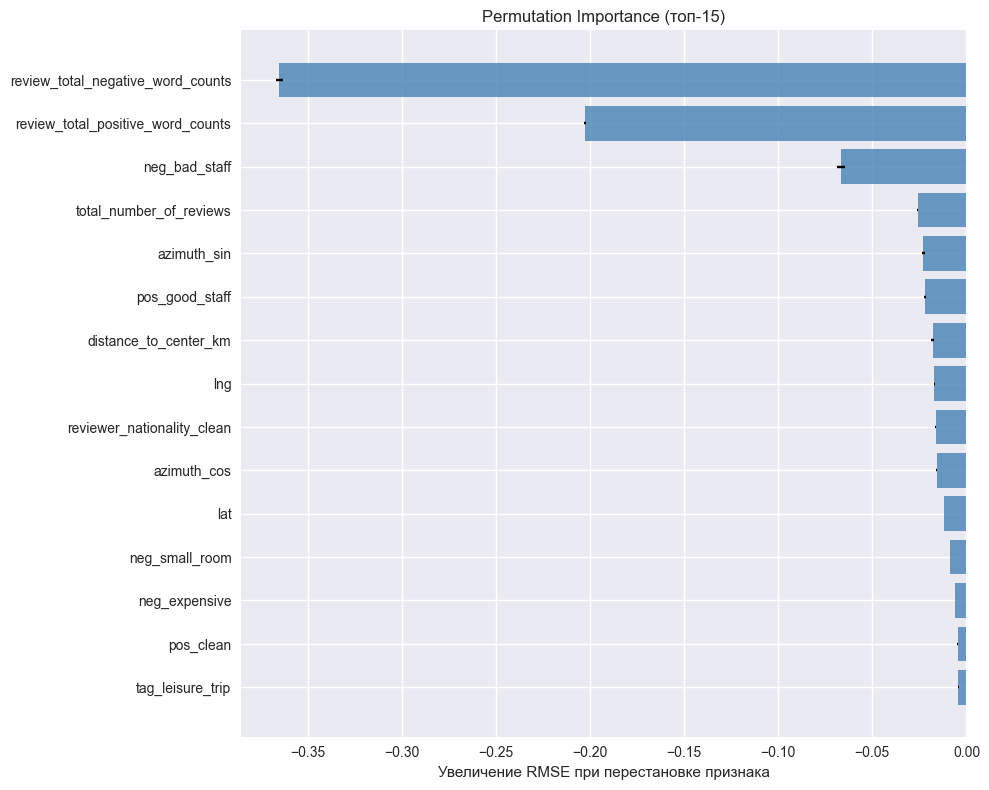

In [657]:
# Топ-15
top_n = 15
top_indices = indices[:top_n]

plt.figure(figsize=(10, 8))
plt.barh(
    range(top_n),
    -perm_imp.importances_mean[top_indices],
    xerr=perm_imp.importances_std[top_indices],
    color='steelblue', 
    alpha=0.8
)
plt.yticks(range(top_n), [feature_names[i] for i in top_indices])
plt.xlabel('Увеличение RMSE при перестановке признака')
plt.title('Permutation Importance (топ-15)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## <font color='orange'>Вывод:</font>

<font color='lightgreen'>

1. ***Топ-3 самых важных признака:***

review_total_negative_word_counts → ΔRMSE = 0.3676

review_total_positive_word_counts → ΔRMSE = 0.2045

neg_bad_staff → ΔRMSE = 0.0696

2. ***Геопризнаки работают:***

distance_to_center_km: ΔRMSE = 0.0249 → значим

azimuth_sin / azimuth_cos: 0.0238 / 0.0124 → полезны

azimuth_from_center: 0.0078 → избыточен (можно удалить)

**→ Оставляем distance_to_center_km, azimuth_sin, azimuth_cos.**

3. ***Теги и национальность — слабые, но полезные***

tag_leisure_trip: ΔRMSE = 0.0044 → можно оставить

reviewer_nationality_clean: ΔRMSE = 0.0122 → важен! (культурный фактор)

city: ΔRMSE = 0.0035 → слабый, но логичен

**→ Оставляем оба — они интерпретируемы и дешевы.**


## 3.3.4 Улучшение модели

**Удалим слабые признаки**

In [658]:
# просто убедиться, что X — это копия
feature_cols = [col for col in hotels_df.columns if col != 'reviewer_score']
X = hotels_df[feature_cols].copy()  # ← для безопасного удаления
y = hotels_df['reviewer_score']

# Теперь можно безопасно удалять
weak_features = [
    'hotel_country',
    'reviewer_region',
    'azimuth_from_center',
    'review_season'
]

X.drop(columns=weak_features, inplace=True)

# Обновляем cat_features
cat_features = [f for f in cat_features if f not in weak_features]

In [659]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3.0,
    task_type="GPU",
    devices="0",
    cat_features=cat_features,
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

Финальная подготовка данных

In [660]:
# Убедимся, что X — копия
feature_cols = [col for col in hotels_df.columns if col != 'reviewer_score']
X = hotels_df[feature_cols].copy()
y = hotels_df['reviewer_score']

# Удалим слабые признаки
weak_features = ['hotel_country', 'reviewer_region', 'review_season']
X.drop(columns=weak_features, errors='ignore', inplace=True)

# Обновим cat_features
cat_features = [f for f in X.select_dtypes(include=['object']).columns.tolist() if f in X.columns]

print(f"✅ Окончательное число признаков: {X.shape[1]}")

✅ Окончательное число признаков: 35


Разделение

In [661]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Финальная модель на GPU

Важность признаков (встроенная)

In [662]:
# Встроенная важность CatBoost
feature_importance = model_final.get_feature_importance(prettified=True)
print("\nТоп-15 признаков по важности (CatBoost):")
print(feature_importance.head(20))


Топ-15 признаков по важности (CatBoost):
                                    Feature Id  Importances
0            review_total_negative_word_counts    22.789959
1            review_total_positive_word_counts    17.672145
2                      total_number_of_reviews     8.001099
3                                  azimuth_sin     6.015553
4                                          lng     4.941548
5                                  azimuth_cos     4.878747
6                                          lat     4.680857
7                        distance_to_center_km     4.023793
8                   reviewer_nationality_clean     3.594052
9                                neg_bad_staff     3.589396
10                              pos_good_staff     2.909757
11                                       index     2.641994
12  total_number_of_reviews_reviewer_has_given     2.249102
13                            tag_leisure_trip     1.505261
14                              neg_small_room     1.30129

Создаем функцию полного пайплайна

In [663]:
def preprocess(df):
    df = df.copy()

    # === 1. Извлекаем город из адреса, если city отсутствует ===
    if 'city' not in df.columns and 'hotel_address' in df.columns:
        def extract_city_simple(address):
            address = str(address).lower()
            if 'london' in address:
                return 'London'
            elif 'paris' in address:
                return 'Paris'
            elif 'amsterdam' in address:
                return 'Amsterdam'
            elif 'milan' in address or 'milano' in address:
                return 'Milan'
            elif 'vienna' in address or 'wien' in address:
                return 'Vienna'
            elif 'barcelona' in address:
                return 'Barcelona'
            else:
                return 'London'
        df['city'] = df['hotel_address'].apply(extract_city_simple)

    # === 2. Обработка временных признаков ===
    if 'review_date' in df.columns:
        df['review_date'] = pd.to_datetime(df['review_date'], format='%m/%d/%Y')
        df['review_year'] = df['review_date'].dt.year
        df['is_weekend'] = df['review_date'].dt.dayofweek.isin([5, 6])
        df['review_season'] = df['review_date'].dt.month.apply(get_season_num)

    if 'days_since_review' in df.columns:
        df['days_since_review'] = (
            df['days_since_review']
            .astype(str)
            .str.extract(r'(\d+)')
            .astype(float)
        )

    # === 3. Геопризнаки ===
    if 'hotel_name' in df.columns and 'lat' in df.columns and 'lng' in df.columns:
        # Обновление координат из словаря
        for hotel, (lat, lng) in manual_coords.items():
            mask = df['hotel_name'] == hotel
            if mask.any():
                df.loc[mask, 'lat'] = lat
                df.loc[mask, 'lng'] = lng

        # Заполнение остатков медианой по городу
        if 'city' in df.columns:
            df['lat'] = df.groupby('city')['lat'].transform(lambda x: x.fillna(x.median()))
            df['lng'] = df.groupby('city')['lng'].transform(lambda x: x.fillna(x.median()))

            # Расстояние до центра
            df['center_lat'] = df['city'].map(lambda c: city_centers[c][0])
            df['center_lng'] = df['city'].map(lambda c: city_centers[c][1])
            df['distance_to_center_km'] = measure_distance(
                df['lat'], df['lng'],
                df['center_lat'], df['center_lng']
            )
            df['distance_to_center_km'] = df['distance_to_center_km'].round()

            # Азимут
            azimuth_deg = calculate_azimuth_deg(
                df['center_lat'], df['center_lng'],
                df['lat'], df['lng']
            )
            azimuth_deg_rounded = (azimuth_deg * 2).round() / 2
            df['azimuth_from_center'] = azimuth_deg_rounded
            azimuth_rad_rounded = np.radians(azimuth_deg_rounded)
            df['azimuth_sin'] = np.sin(azimuth_rad_rounded)
            df['azimuth_cos'] = np.cos(azimuth_rad_rounded)

            df.drop(columns=['center_lat', 'center_lng'], inplace=True)

    # === 4. Очистка отзывов ===
    if 'positive_review' in df.columns:
        df['positive_review'] = df['positive_review'].apply(clean_review)
    if 'negative_review' in df.columns:
        df['negative_review'] = df['negative_review'].apply(clean_review)

    # Удаляем старые категориальные признаки отзывов
    cols_to_drop = [col for col in df.columns if col.startswith(('neg_', 'pos_'))]
    df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

    # Создаём новые
    if 'negative_review' in df.columns:
        create_category_features(df, 'negative_review', NEGATIVE_CATEGORIES, 'neg')
    if 'positive_review' in df.columns:
        create_category_features(df, 'positive_review', POSITIVE_CATEGORIES, 'pos')
    df.drop(columns=['neg_parking_problem'], errors='ignore', inplace=True)

    # === 5. Национальность и страна ===
    if 'reviewer_nationality' in df.columns:
        df['reviewer_nationality'] = df['reviewer_nationality'].str.strip()
        df['reviewer_nationality_clean'] = (
            df['reviewer_nationality']
            .where(df['reviewer_nationality'].isin(top15_nats), 'Other')
        )

    if 'hotel_address' in df.columns:
        df['hotel_country'] = df['hotel_address'].apply(extract_country)
        df['reviewer_region'] = df['reviewer_nationality'].map(country_to_region).fillna('Other')
        df['hotel_region'] = df['hotel_country'].map(country_to_region).fillna('Other')
        df['is_domestic_trip'] = (df['reviewer_nationality'] == df['hotel_country'])
        df['is_regional_trip'] = (df['reviewer_region'] == df['hotel_region'])

    # === 6. Теги ===
    if 'tags' in df.columns:
        df['parsed_tags'] = df['tags'].apply(parse_tags)
        df['tag_is_family'] = df['parsed_tags'].apply(
            lambda tags: ('Family with young children' in tags) or ('Family with older children' in tags)
        )
        other_tags = ['Leisure trip', 'Business trip', 'Couple', 'Solo traveler', 'Group']
        for tag in other_tags:
            col_name = f"tag_{tag.lower().replace(' ', '_')}"
            df[col_name] = df['parsed_tags'].apply(lambda tags: tag in tags)
        df.drop(columns=['tag_business_trip'], errors='ignore', inplace=True)

    # === 7. Финальная очистка ===
    cols_to_remove = [
        'hotel_name', 'hotel_address', 'review_date', 'reviewer_nationality', 'tags',
        'parsed_tags', 'positive_review', 'negative_review', 'days_since_review',
        'average_score', 'additional_number_of_scoring',
        'hotel_country', 'reviewer_region', 'review_season'
    ]
    df.drop(columns=[c for c in cols_to_remove if c in df.columns], inplace=True)

    return df

In [664]:
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
print("Test index name:", test_df.index.name)
print("Test index values (first 5):", test_df.index[:5].tolist())

Train columns: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'tags', 'days_since_review', 'lat', 'lng']
Test columns: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'tags', 'days_since_review', 'lat', 'lng']
Test index name: None
Test index values (first 5): [0, 1, 2, 3, 4]


In [665]:
# Для train
train_df = pd.read_csv('hotels_train.csv')
# Для test
test_df = pd.read_csv('hotels_test.csv')

sample_submission = pd.read_csv('submission.csv')

# Теперь 'id' — обычная колонка
print("Train columns:", train_df.columns.tolist())
print("Test columns:", test_df.columns.tolist())
# Обрабатываем
X_train = preprocess(train_df)
y_train = train_df['reviewer_score']

X_test = preprocess(test_df)  # без y!

# Убедимся, что колонки совпадают
common_cols = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_cols]
X_test = X_test[common_cols]

# Обучение
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

model = CatBoostRegressor(
    iterations=10000,
    learning_rate=0.01,
    depth=10,
    l2_leaf_reg=3,
    cat_features=cat_features,
    task_type="GPU",
    devices="0",
    eval_metric='MAPE',
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train)

# Предсказание
preds = model.predict(X_test)



Train columns: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'reviewer_score', 'tags', 'days_since_review', 'lat', 'lng']
Test columns: ['hotel_address', 'additional_number_of_scoring', 'review_date', 'average_score', 'hotel_name', 'reviewer_nationality', 'negative_review', 'review_total_negative_word_counts', 'total_number_of_reviews', 'positive_review', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'tags', 'days_since_review', 'lat', 'lng']
0:	learn: 0.1942479	total: 30.6ms	remaining: 5m 5s
100:	learn: 0.1541461	total: 3.14s	remaining: 5m 7s
200:	learn: 0.1424472	total: 6.25s	remaining: 5m 4s
300:	learn: 0.1379469	total: 9.62s	remaining: 5m 10s
400:	learn: 0.1356417	total: 12.9s	remaining: 5m 

In [666]:
submission = sample_submission.copy()
submission['reviewer_score'] = preds
submission.to_csv('output/submission.csv', index=False)

## <font color='orange'> Итог:</font>

<font color='lightgreen'>

С первого раза удалось достичь MAPE = 12.99, изменение настроек обучения модели - глубина =10, число итераций =10000 дали незначительный, но прирост до 12,94662, что уже неплохо, учитывая стартовые позиции. Постанализ установил, что если оставить Долготу и Широту, то это улучшает качество предсказания, пускай и немного. Было также решено оставить asimuth_from_center, что также дало прирост до 12,94508, далее настройки l2_leaf_reg=3 также позволили незначително улучшить показатель до 12,83906. Попытка увеличить число итераций или глубину приводили к переобучению модели и ухудшению результата.

Однако видно, что показатель может быть еще выше - явно требуется более глубокая проработка отзывов.

**Идеи:**

1. Возможно требуется проверить комбинации признаков, которые были извлечены из отзывов. В отличии от позитивных отызвов и объективных факторов (например расстояние до центра),
субъективное восриятие сложнее для анализа - явных сильных сигналов для низкого рейтинга не видно с первого раза.

2. Также следует попробовать другие модели, например LGBM

В ближайшем будущем постараюсь улучшить результат еще больше